<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >PRUEBA S4 PERIODO 2023-2026 </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  02/09/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2026</strong></p>
</div>

---

**1. LECTURA DE DATOS**

In [1]:
PATH      = "/home/soporte/Documents/pipelines_cip/S4_LISN/processed_s4"
filename  = "df_max_s4_all_jic.csv"

In [2]:
import os
import pandas as pd

file_dir = os.path.join(PATH,filename)
s4_param = pd.read_csv(file_dir)
s4_param.head()

,Datetime,ID_Satelite,S4,Azimuth,Elevacion
0,2023-01-01 00:01:00,9,0.092,186.0,41.0
1,2023-01-01 00:02:00,9,0.092,186.0,41.0
2,2023-01-01 00:03:00,9,0.092,185.0,40.0
3,2023-01-01 00:04:00,9,0.138,185.0,40.0
4,2023-01-01 00:05:00,6,0.093,226.0,44.0


In [3]:
# Supongamos que tu DataFrame se llama df
#s4_param["Tiempo"] = pd.to_datetime(s4_param["Tiempo"])  # aseguramos que es tipo datetime
s4_param["Datetime"] = pd.to_datetime(s4_param["Datetime"])  # aseguramos que es tipo datetime

# Extraer los años únicos
#years = s4_param["Tiempo"].dt.year.unique().tolist()
years = s4_param["Datetime"].dt.year.unique().tolist()


print(f"La Lista de años es years: {years}")
print("\n")
# ORDENAR EL DATASET POR TIEMPO
#s4_param =  s4_param.sort_values(by="Tiempo")
s4_param =  s4_param.sort_values(by="Datetime")

s4_param.head()

La Lista de años es years: [2023, 2024, 2025, 2026]




,Datetime,ID_Satelite,S4,Azimuth,Elevacion
0,2023-01-01 00:01:00,9,0.092,186.0,41.0
1,2023-01-01 00:02:00,9,0.092,186.0,41.0
2,2023-01-01 00:03:00,9,0.092,185.0,40.0
3,2023-01-01 00:04:00,9,0.138,185.0,40.0
4,2023-01-01 00:05:00,6,0.093,226.0,44.0


In [4]:
print("Cantidad del dataset: ",len(s4_param))
print("Ultimo dato:          ",s4_param.tail(1))
s4_param.describe()

Cantidad del dataset:  1447065
Ultimo dato:                              Datetime  ID_Satelite     S4  Azimuth  Elevacion
1447064 2026-08-31 23:45:00           58  0.134    155.0       40.0


,Datetime,ID_Satelite,S4,Azimuth,Elevacion
count,1447065,1.447065e+06,1.447065e+06,1.447065e+06,1.447065e+06
mean,2025-01-31 00:09:43.462470656,3.316255e+01,1.343662e-01,1.783619e+02,3.782837e+01
min,2023-01-01 00:01:00,2.000000e+00,0.000000e+00,0.000000e+00,3.100000e+01
25%,2024-05-21 23:14:00,1.200000e+01,1.040000e-01,1.600000e+02,3.300000e+01
50%,2025-02-12 11:34:00,2.700000e+01,1.250000e-01,1.800000e+02,3.600000e+01
75%,2025-11-11 05:58:00,5.000000e+01,1.490000e-01,2.050000e+02,4.100000e+01
max,2026-08-31 23:45:00,1.060000e+02,1.466000e+00,3.590000e+02,9.000000e+01
std,NaN,2.391535e+01,5.574138e-02,3.622324e+01,5.825876e+00


# **GRAFICOS**

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Convert UTC → Local Time (UTC - 5)
# ============================================================
def to_local_time(df, time_col):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col]) - pd.Timedelta(hours=5)
    return df


# ============================================================
# Continuous nocturnal minute in LOCAL TIME
# ============================================================
def nocturnal_minute_lt(dt):
    h, m = dt.hour, dt.minute

    if h >= 18:
        return (h - 18) * 60 + m
    elif h < 6:
        return (h + 6) * 60 + m
    elif h == 6 and m == 0:
        return 720
    else:
        return np.nan


# ============================================================
# Annual S4 plot
# ============================================================
def plot_s4_year_minute(df, year, station_name="STATION", save_fig=False, out_dir="./"):

    df = to_local_time(df, "TIME")
    df_year = df[df["TIME"].dt.year == year].copy()

    if df_year.empty:
        raise ValueError(f"No data available for year {year}")

    df_year["Nocturnal_Minute"] = df_year["TIME"].apply(nocturnal_minute_lt)
    df_year = df_year.dropna(subset=["Nocturnal_Minute"])

    if df_year.empty:
        raise ValueError("No nocturnal data available")

    # ---- Date limits
    first_dt = df_year["TIME"].min()
    last_dt  = df_year["TIME"].max()

    first_month = first_dt.replace(day=1)
    last_month  = last_dt.replace(day=1) + pd.offsets.MonthEnd(0)

    full_dates = pd.date_range(first_month, last_month, freq="D")
    date_to_idx = {d.date(): i for i, d in enumerate(full_dates)}

    nocturnal_minutes = np.arange(0, 721)
    Z = np.full((len(nocturnal_minutes), len(full_dates)), np.nan)

    # ---- Fill matrix
    for _, row in df_year.iterrows():
        night_date = row["TIME"].date()
        if row["TIME"].hour <= 6:
            night_date = (row["TIME"] - pd.Timedelta(days=1)).date()

        i = int(row["Nocturnal_Minute"])
        j = date_to_idx.get(night_date)

        if j is not None and 0 <= i < Z.shape[0]:
            Z[i, j] = row["S4"]

    # ========================================================
    # MONTH LABELS (SPANISH - UPPERCASE)
    # ========================================================
    months = pd.date_range(first_month, last_month, freq="MS")

    month_positions = [(m.date() - full_dates[0].date()).days for m in months]

    month_labels = [
        m.strftime("%b").upper()
        .replace("JAN", "ENE")
        .replace("FEB", "FEB")
        .replace("MAR", "MAR")
        .replace("APR", "ABR")
        .replace("MAY", "MAY")
        .replace("JUN", "JUN")
        .replace("JUL", "JUL")
        .replace("AUG", "AGO")
        .replace("SEP", "SEP")
        .replace("OCT", "OCT")
        .replace("NOV", "NOV")
        .replace("DEC", "DIC")
        for m in months
    ]

    # ========================================================
    # PLOT
    # ========================================================
    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        cmap="jet",
        vmin=0.0,
        vmax=0.6,
        interpolation="nearest",
        extent=[0, Z.shape[1], 0, Z.shape[0]]
    )

    # ---- Y AXIS (UPPERCASE)
    hour_ticks = np.arange(0, 721, 60)
    hour_labels = ["18","19","20","21","22","23",
                   "00","01","02","03","04","05","06"]

    ax.set_yticks(hour_ticks)
    ax.set_yticklabels(hour_labels)

    ax.set_ylabel("LOCAL TIME (LT)", fontsize=12)

    # ---- X AXIS (UPPERCASE)
    ax.set_xticks(month_positions)
    ax.set_xticklabels(month_labels)

    ax.set_xlabel("MONTHS", fontsize=12)

    # ---- TITLE (UPPERCASE)
    ax.set_title(
        f"NOCTURNAL IONOSPHERIC SCINTILLATION INDEX (S4)\n"
        f"DAILY–MINUTE RESOLUTION (18:00–06:00 LT) – {year}\n"
        f"STATION: {station_name}",
        fontsize=12
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("S4 INDEX")

    plt.tight_layout()
    os.makedirs(out_dir, exist_ok=True)

    if save_fig:
        station_clean = station_name.replace(" ", "_")
        filename = f"{station_clean}_S4_NOCTURNAL_{year}.png"

        plt.savefig(
            f"{out_dir}/{filename}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

# **PERIODO 2023**

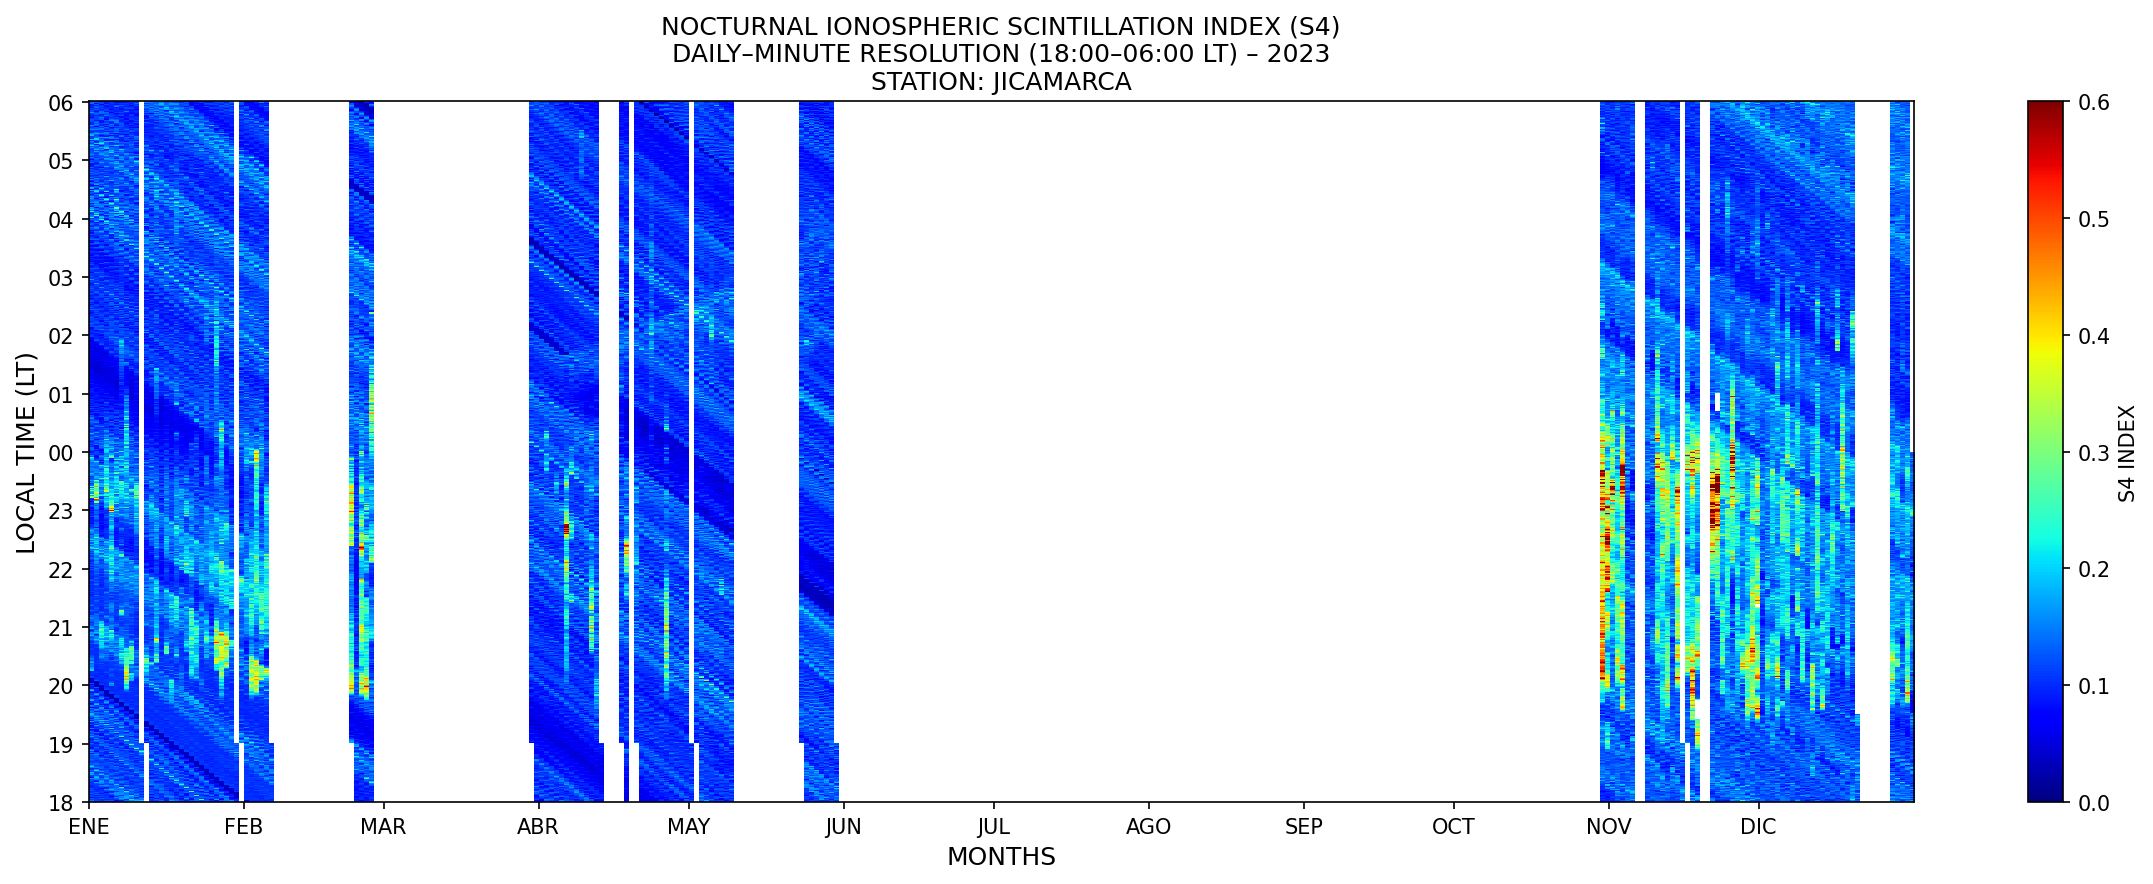

In [9]:
# ============================================================
# USAGE
# ============================================================
#s4_param_HYO["Tiempo"] = pd.to_datetime(s4_param_HYO["Tiempo"])
s4_param["TIME"] = pd.to_datetime(s4_param["Datetime"])

#plot_s4_year_minute(s4_param_HYO, 2025)
plot_s4_year_minute(s4_param, 2023, station_name="JICAMARCA",save_fig=True,out_dir="figures")

# **PERIODO 2024**

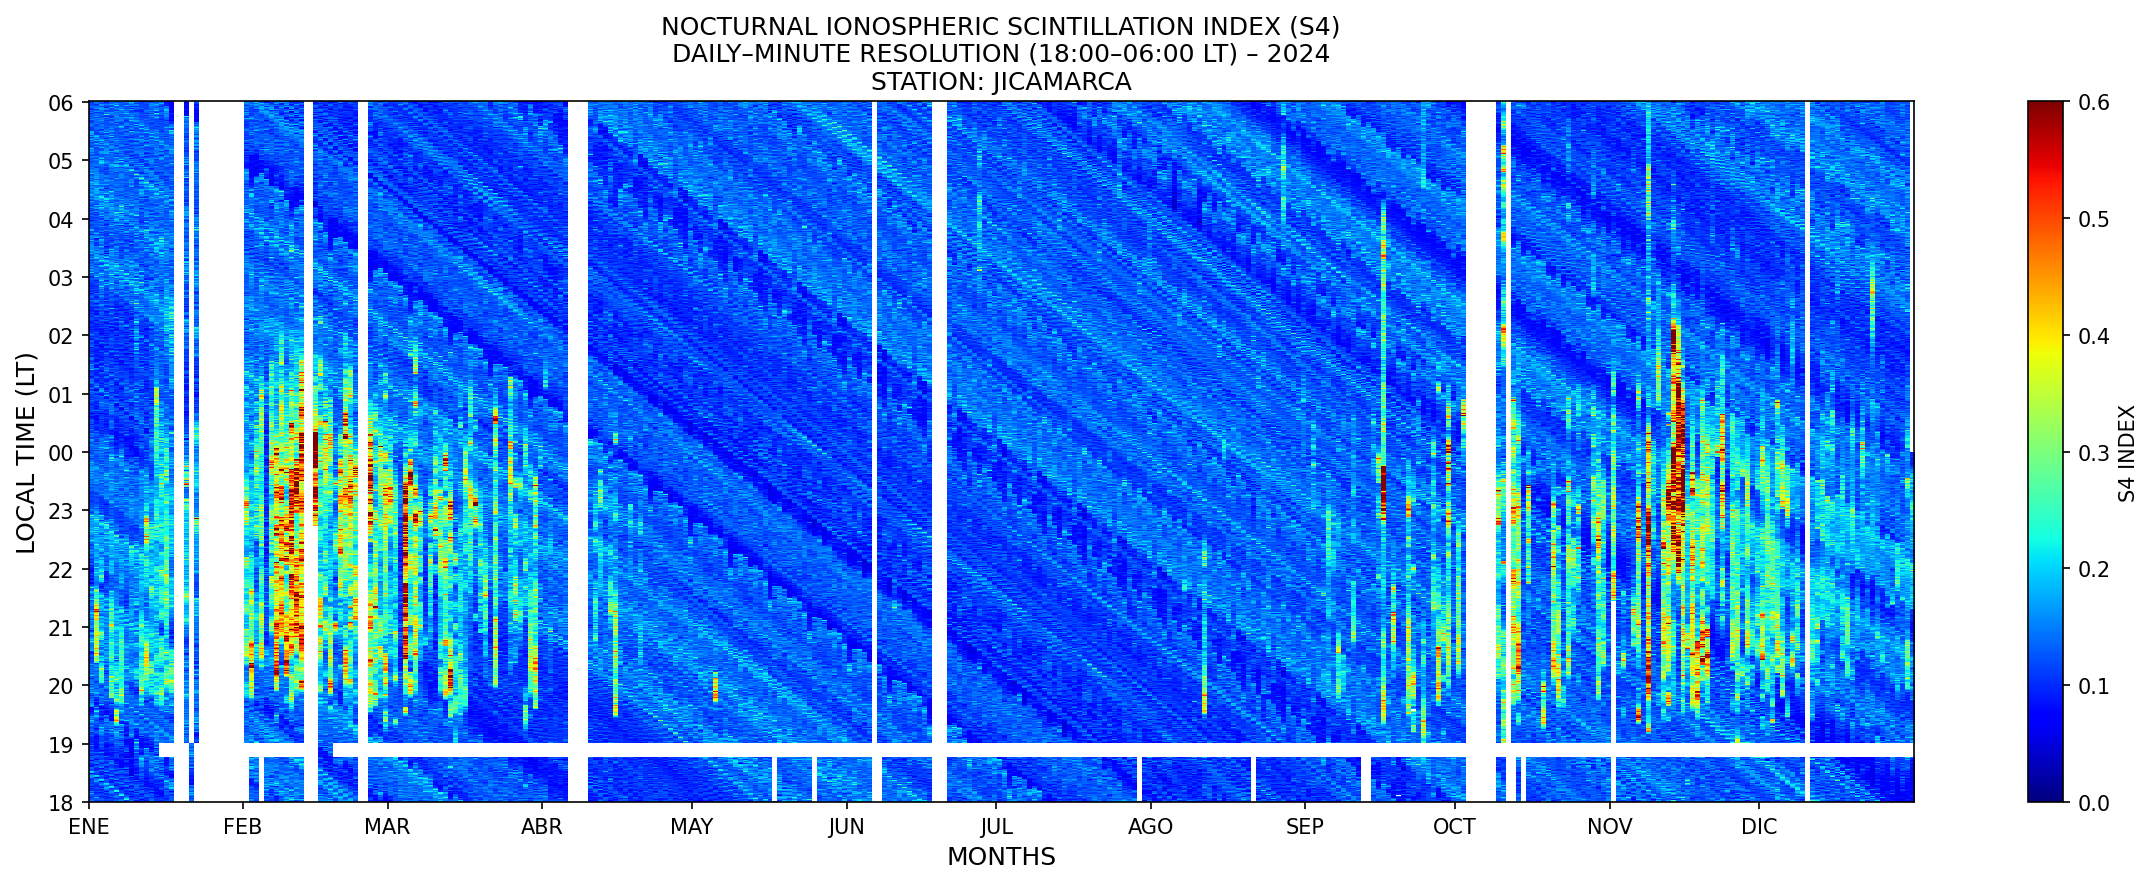

In [8]:
# ============================================================
# USAGE
# ============================================================
#s4_param_HYO["Tiempo"] = pd.to_datetime(s4_param_HYO["Tiempo"])
s4_param["TIME"] = pd.to_datetime(s4_param["Datetime"])

#plot_s4_year_minute(s4_param_HYO, 2025)
plot_s4_year_minute(s4_param, 2024, station_name="JICAMARCA",save_fig=True,out_dir="figures")

# **PERIODO 2025**

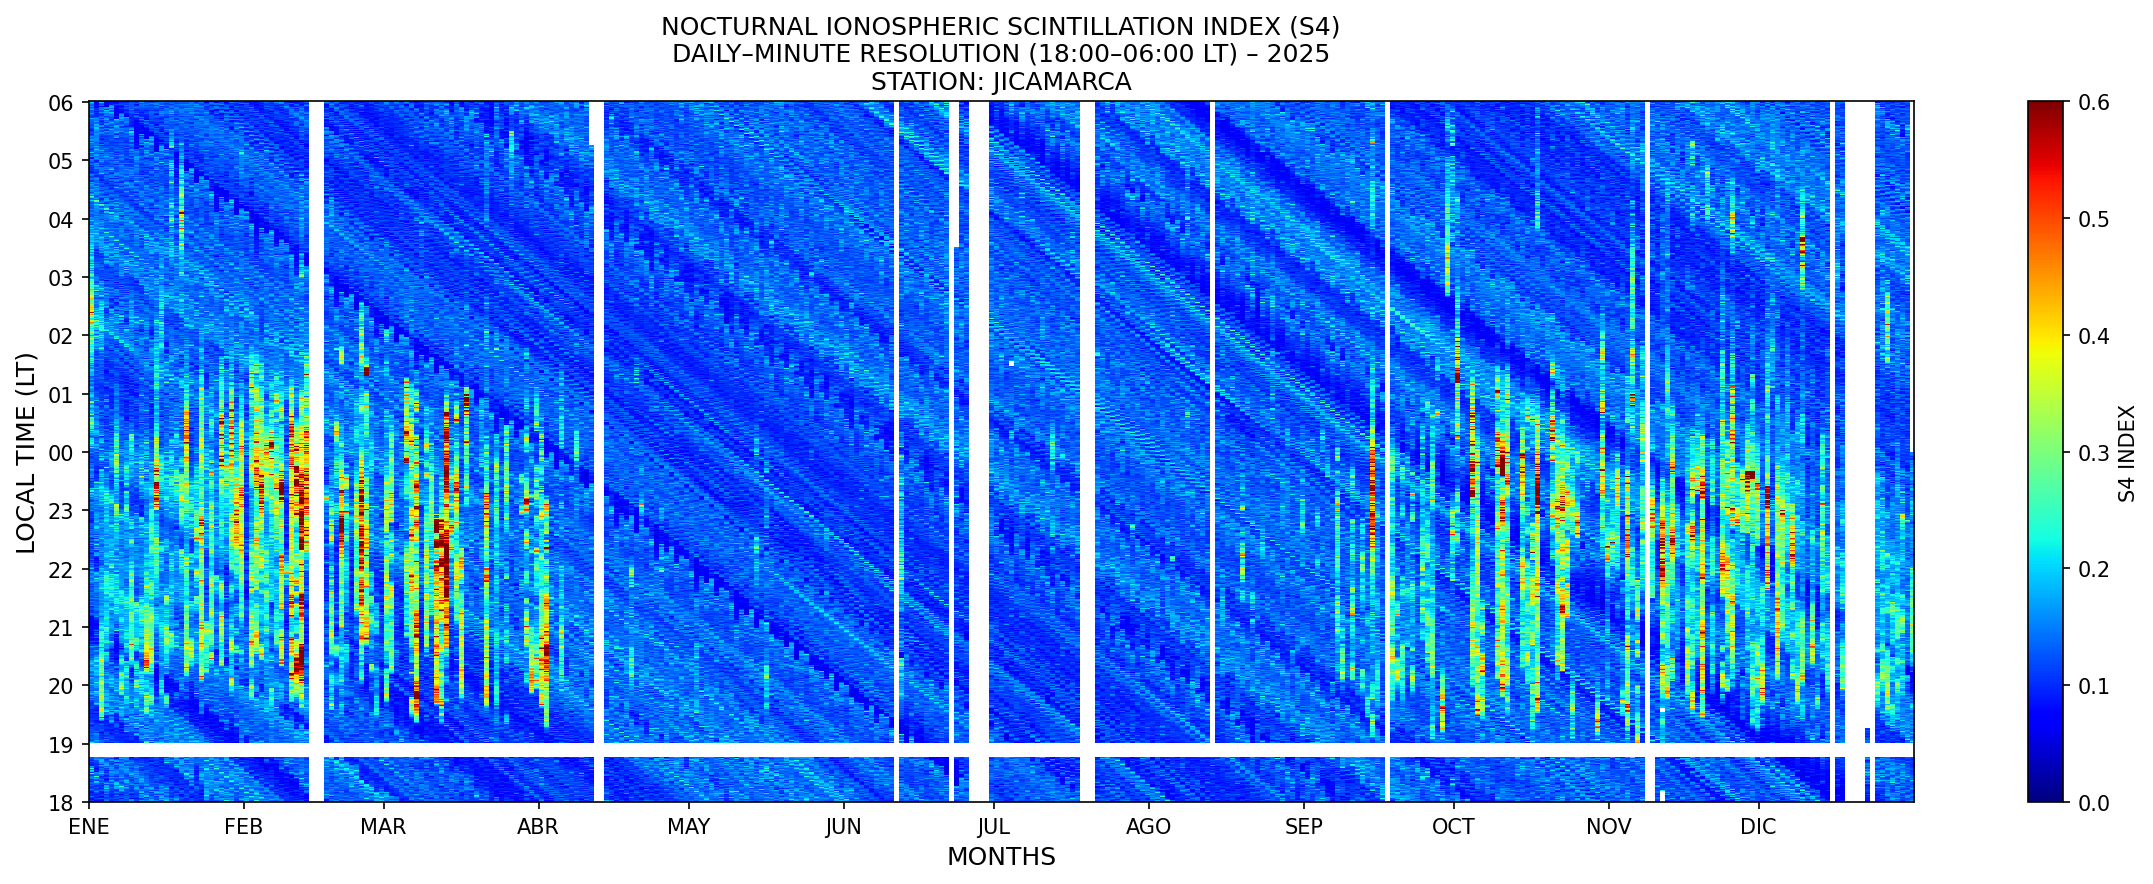

In [7]:
# ============================================================
# USAGE
# ============================================================
#s4_param_HYO["Tiempo"] = pd.to_datetime(s4_param_HYO["Tiempo"])
s4_param["TIME"] = pd.to_datetime(s4_param["Datetime"])

#plot_s4_year_minute(s4_param_HYO, 2025)
plot_s4_year_minute(s4_param, 2025, station_name="JICAMARCA",save_fig=True,out_dir="figures")

# **PERIODO 2026**

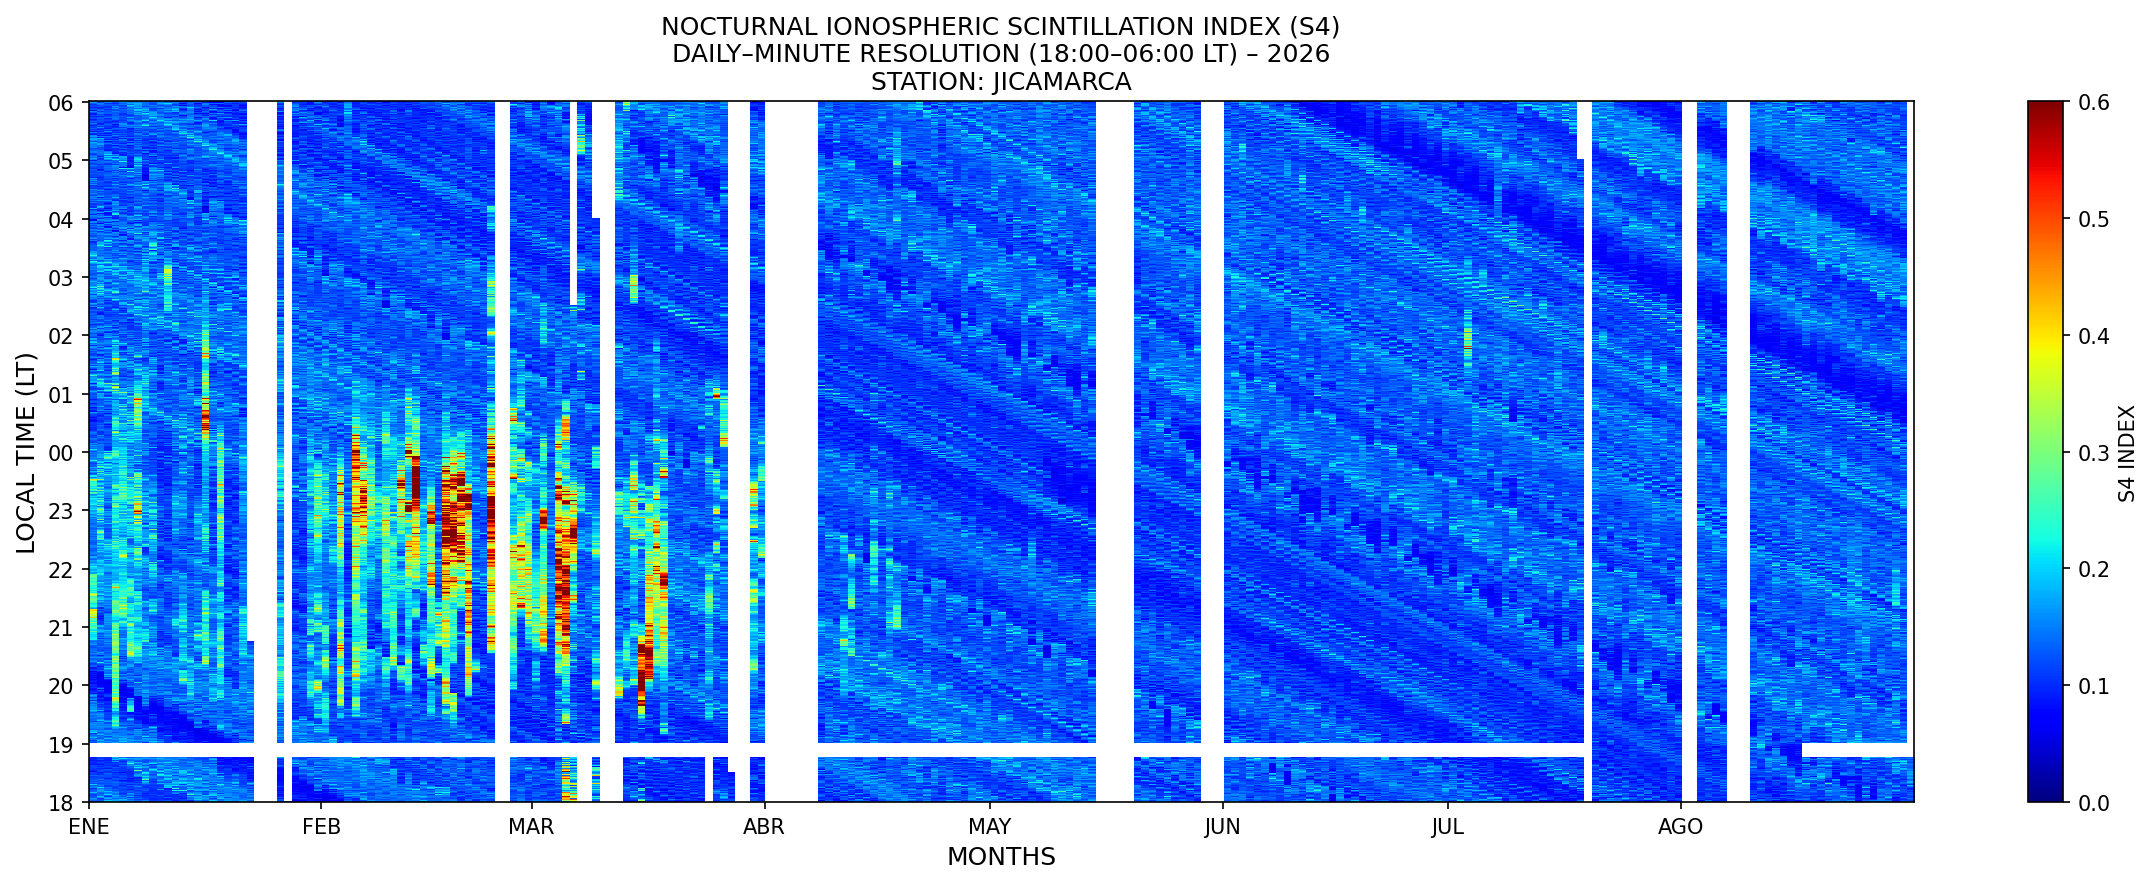

In [6]:
# ============================================================
# USAGE
# ============================================================
#s4_param_HYO["Tiempo"] = pd.to_datetime(s4_param_HYO["Tiempo"])
s4_param["TIME"] = pd.to_datetime(s4_param["Datetime"])

#plot_s4_year_minute(s4_param_HYO, 2025)
plot_s4_year_minute(s4_param, 2026, station_name="JICAMARCA",save_fig=True,out_dir="figures")

# I. ETAPA I:
1. Configuracion y constantes
2. Funciones de carga y analisis
3. Ingenieria de Caracteristicas
4. Finalizar estructura del df
5. División estratificada
6. Auditar división de datos
7. Normalización
8. Ejecución del pipeline(main)

## **1. LIMPIEZA,PRE-PROCESAMIENTO Y VISUALIZACION DE EVENTOS**

In [33]:
# =============================================================================
# 1. CONFIGURACIÓN
# =============================================================================
import os
import warnings
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
warnings.filterwarnings("ignore")
# -----------------------------
# Parámetros principales
# -----------------------------
TARGET_COL = "S4"
# El criterio científico Utilizado es S4 mayor o igual a 0.6 plasmado en la metodología de la tesis.
S4_EVENT_THRESHOLD = 0.6

# Si son None, NO se impone una duración científica que no haya sido definida.
MIN_EVENT_DURATION = None          # minutos
MAX_GAP_BETWEEN_EVENTS = None      # minutos

LOOKBACK = 70
HORIZON = 10                        # cambiar a 15 para el segundo experimento

SAMPLING_MINUTES = 1
# TENTATIVOS
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
# Número mínimo deseado de eventos por partición.
# No se fuerza artificialmente si la serie no lo permite.
MIN_EVENTS_TRAIN = 1
MIN_EVENTS_VAL   = 1
MIN_EVENTS_TEST  = 1
# Scaler configurable: "minmax" o "standard"
SCALER_TYPE = "minmax"
# Si True, se evalúan cortes diarios alternativos buscando una mejor
# representación de eventos sin romper la cronología.
SEARCH_EVENT_AWARE_SPLIT = True

# Variables candidatas al modelo.
# S4 se mantiene como predictor histórico y como variable objetivo futura.
#FEATURES_COLS = ["TEC","ROTEC","ROTI","Kp_Index","Dst_Index","AE_Index","f10.7_Index","daily_sin","daily_cos","day_of_year_sin","day_of_year_cos","S4"]


assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

print("Configuración cargada.")
print(f"Umbral de evento S4 >= {S4_EVENT_THRESHOLD}")
print(f"LOOKBACK = {LOOKBACK} min | HORIZON = {HORIZON} min")
print(f"Sampling esperado = {SAMPLING_MINUTES} min")

Configuración cargada.
Umbral de evento S4 >= 0.6
LOOKBACK = 70 min | HORIZON = 10 min
Sampling esperado = 1 min


In [37]:
# =====================================================================
# 0. CARGAR DATASET
# =====================================================================
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)

    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Datetime"])

    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

# =====================================================================
# 1. CONVERSION DE COLUMAN TEMPORAL A DATETIME 
# =====================================================================

def sort_temporally(df, time_col="Tiempo"):
    """
    Convierte la columna temporal a datetime,
    establece Tiempo como índice y ordena cronológicamente.
    """

    out = df.copy()

    # ---------------------------------------------------------
    # 1. Verificar que exista la columna temporal
    # ---------------------------------------------------------
    if time_col not in out.columns:
        raise ValueError(f"No existe la columna temporal '{time_col}'.")

    # ---------------------------------------------------------
    # 2. Convertir la columna Tiempo a datetime
    # ---------------------------------------------------------
    out[time_col] = pd.to_datetime(out[time_col],errors="coerce")

    # ---------------------------------------------------------
    # 3. Detectar fechas que no pudieron convertirse
    # ---------------------------------------------------------
    n_invalid = out[time_col].isna().sum()

    if n_invalid > 0:
        raise ValueError(
            f"Se encontraron {n_invalid:,} valores inválidos "
            f"en la columna '{time_col}'."
        )

    # ---------------------------------------------------------
    # 4. Establecer Tiempo como índice
    # ---------------------------------------------------------
    out = out.set_index(time_col)

    # ---------------------------------------------------------
    # 5. Ordenar cronológicamente
    # ---------------------------------------------------------
    out = out.sort_index()

    # ---------------------------------------------------------
    # 6. Mostrar información de control
    # ---------------------------------------------------------
    print("=" * 80)
    print("ORDENAMIENTO TEMPORAL")
    print("=" * 80)
    print(f"Tipo de índice:     {type(out.index).__name__}")
    print(f"Fecha mínima:       {out.index.min()}")
    print(f"Fecha máxima:       {out.index.max()}")
    print(f"Observaciones:      {len(out):,}")
    print("=" * 80)

    return out
# =============================================================================
# 2. VALIDACIÓN DEL DATASET
# =============================================================================

def validate_dataframe(df, target_col=TARGET_COL):
    """Valida estructura mínima y calidad básica del DataFrame."""

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas.DataFrame.")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(
            "El índice de df debe ser un pandas.DatetimeIndex. "
            "Use df['Tiempo'] y luego df.set_index('Tiempo') si es necesario."
        )

    if target_col not in df.columns:
        raise ValueError(f"No existe la columna objetivo '{target_col}'.")

    if df.empty:
        raise ValueError("El DataFrame está vacío.")

    if df.index.has_duplicates:
        dup = int(df.index.duplicated().sum())
        raise ValueError(f"El índice contiene {dup} timestamps duplicados. ""Deben resolverse antes de crear ventanas."
        )

    if not pd.api.types.is_numeric_dtype(df[target_col]):
        raise TypeError(f"{target_col} debe ser numérica.")

    if df[target_col].isna().any():
        n = int(df[target_col].isna().sum())
        raise ValueError(
            f"S4 contiene {n} valores NaN. "
            "No se deben generar ventanas sobre observaciones objetivo faltantes."
        )

    if not np.isfinite(df[target_col].to_numpy(dtype=float)).all():
        raise ValueError("S4 contiene valores infinitos o no finitos.")

    if not df.index.is_monotonic_increasing:
        print("ADVERTENCIA: el índice no está ordenado. Se ordenará.")

    print("=" * 80)
    print("VALIDACIÓN DEL DATASET")
    print("=" * 80)
    print(f"Filas:              {len(df):,}")
    print(f"Columnas:           {len(df.columns)}")
    print(f"Fecha mínima:       {df.index.min()}")
    print(f"Fecha máxima:       {df.index.max()}")
    print(f"Días calendario:    {df.index.normalize().nunique():,}")
    print(f"Meses calendario:   {df.index.to_period('M').nunique():,}")
    print(f"S4 mínimo:          {df[target_col].min():.6f}")
    print(f"S4 máximo:          {df[target_col].max():.6f}")
    print("=" * 80)

    return True

# =============================================================================
#  EJECUCIÓN DEL PIPELINE (MAIN)
# =============================================================================
if __name__ == "__main__":
#1. Configuracion
    #N_ESTACION = 0 # Escoge la estación
    #ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
    #RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    #ARCHIVO     = f"DF_FINAL_{ESTACION[N_ESTACION]}_{31072026}.csv"
    RUTA      = "/home/soporte/Documents/pipelines_cip/S4_LISN/processed_s4"
    ARCHIVO   = "df_max_s4_all_jic.csv"
    print("="*60)
    #print(f"RUTA DRIVE: {RUTA_DRIVE}")
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)
    
    # ============================================================
    # 2. Pipeline de ejecución
    # ============================================================
    # ------------------------------------------------------------
    # Cargar dataset
    # ------------------------------------------------------------
    df = cargar_dataset(RUTA, ARCHIVO)
    print(df.head())
    # ------------------------------------------------------------
    # Ordenar y establecer Tiempo como índice
    # ------------------------------------------------------------
    df = sort_temporally(df,time_col="Tiempo")
    # ------------------------------------------------------------
    # Validar dataset
    # ------------------------------------------------------------
    validate_dataframe(df)
    print("Dataset listo para el procesamiento temporal.")

RUTA : /home/soporte/Documents/pipelines_cip/S4_LISN/processed_s4
Trabajamos con el archivo: df_max_s4_all_jic.csv
📂 Cargando archivo: df_max_s4_all_jic.csv...
✅ Dataset cargado. Shape: (1447065, 6)
   Rango de fechas: 2023-01-01 00:01:00 a 2026-08-31 23:45:00
              Datetime  ID_Satelite     S4  Azimuth  Elevacion  \
0  2023-01-01 00:01:00            9  0.092    186.0       41.0   
1  2023-01-01 00:02:00            9  0.092    186.0       41.0   
2  2023-01-01 00:03:00            9  0.092    185.0       40.0   
3  2023-01-01 00:04:00            9  0.138    185.0       40.0   
4  2023-01-01 00:05:00            6  0.093    226.0       44.0   

               Tiempo  
0 2023-01-01 00:01:00  
1 2023-01-01 00:02:00  
2 2023-01-01 00:03:00  
3 2023-01-01 00:04:00  
4 2023-01-01 00:05:00  
ORDENAMIENTO TEMPORAL
Tipo de índice:     DatetimeIndex
Fecha mínima:       2023-01-01 00:01:00
Fecha máxima:       2026-08-31 23:45:00
Observaciones:      1,447,065
VALIDACIÓN DEL DATASET
Filas:   

# **3. SELECCIÓN DE VARIABLES Y CALIDAD TEMPORAL**

In [38]:

CASE = 1

FEATURES_CASES = {
    1: [ "S4"],
    2: [ "S4","Kp_Index","Dst_Index","AE_Index","f10.7_Index"],
    3: [ "S4","TEC","ROTEC","ROTI","Kp_Index","Dst_Index","AE_Index","f10.7_Index"],
}

SELECTED_COLUMNS = FEATURES_CASES[CASE]

df = df[SELECTED_COLUMNS].copy()

print("\n" + "=" * 80)
print(f"CASO {CASE} - VARIABLES SELECCIONADAS")
print("=" * 80)
print(f"Columnas: {SELECTED_COLUMNS}")
print("=" * 80)

# =============================================================================
# 3. CALIDAD TEMPORAL: GAPS Y DÍAS INCOMPLETOS
# =============================================================================

def validate_gaps(df, expected_minutes=SAMPLING_MINUTES):
    """Detecta gaps y resume calidad temporal sin asumir 1440 filas por día."""

    idx = pd.DatetimeIndex(df.index)
    delta = idx.to_series().diff()

    gaps = delta[delta > pd.Timedelta(minutes=expected_minutes)]
    duplicates = delta[delta == pd.Timedelta(0)]

    daily = pd.DataFrame(index=idx)
    daily["date"] = idx.normalize()

    daily_summary = (daily.groupby("date").size().rename("observations").to_frame()
    )

    daily_summary["complete_1440"] = daily_summary["observations"] == 1440
    daily_summary["incomplete"] = daily_summary["observations"] < 1440

    # Un día puede tener >1440 observaciones en datasets con duplicados,
    # aunque los duplicados ya se auditan antes.
    daily_summary["has_gap"] = False

    for date, group in pd.Series(idx, index=idx).groupby(idx.normalize()):
        d = group.sort_values().diff()
        if (d > pd.Timedelta(minutes=expected_minutes)).any():
            daily_summary.loc[date, "has_gap"] = True

    gap_report = pd.DataFrame({
        "gap_start": gaps.index[:-0] if False else gaps.index,
        "gap_duration": gaps.values
    })

    print("\n" + "=" * 80)
    print("REPORTE DE CALIDAD TEMPORAL")
    print("=" * 80)
    print(f"Observaciones:                  {len(idx):,}")
    print(f"Intervalos > {expected_minutes} min:       {len(gaps):,}")
    print(f"Intervalos duplicados:           {len(duplicates):,}")
    print(f"Días registrados:                {len(daily_summary):,}")
    print(f"Días con 1440 observaciones:     {daily_summary['complete_1440'].sum():,}")
    print(f"Días con <1440 observaciones:    {daily_summary['incomplete'].sum():,}")
    print(f"Días con gaps:                   {daily_summary['has_gap'].sum():,}")

    if len(gaps):
        print("\nPrimeros gaps:")
        print(gap_report.head(10))

    return {
        "gaps": gap_report,
        "daily_quality": daily_summary,
    }


quality_report = validate_gaps(df)


CASO 1 - VARIABLES SELECCIONADAS
Columnas: ['S4']

REPORTE DE CALIDAD TEMPORAL
Observaciones:                  1,447,065
Intervalos > 1 min:       980
Intervalos duplicados:           0
Días registrados:                1,064
Días con 1440 observaciones:     142
Días con <1440 observaciones:    922
Días con gaps:                   64

Primeros gaps:
            gap_start     gap_duration
0 2023-01-03 12:50:00  0 days 00:03:00
1 2023-01-03 12:53:00  0 days 00:02:00
2 2023-01-03 12:55:00  0 days 00:02:00
3 2023-01-13 00:01:00  1 days 00:01:00
4 2023-02-01 00:01:00  1 days 00:01:00
5 2023-02-23 00:01:00 16 days 00:01:00
6 2023-02-23 22:26:00  0 days 00:04:00
7 2023-02-23 22:29:00  0 days 00:03:00
8 2023-03-31 00:01:00 31 days 11:20:00
9 2023-04-18 00:01:00  4 days 00:01:00


In [39]:
# =============================================================================
# 4. IDENTIFICACIÓN DE EVENTOS INDEPENDIENTES
# =============================================================================

def identify_events(
    df,
    target_col=TARGET_COL,
    threshold=S4_EVENT_THRESHOLD,
    min_duration=MIN_EVENT_DURATION,
    max_gap_between_events=MAX_GAP_BETWEEN_EVENTS,
    expected_minutes=SAMPLING_MINUTES,
):
    """
    Identifica eventos independientes de S4.

    - Evento básico: S4 >= threshold.
    - Un gap de adquisición (timestamp consecutivo > expected_minutes)
      SIEMPRE rompe un evento.
    - Si max_gap_between_events no es None, permite unir dos tramos activos
      separados por observaciones existentes por debajo del umbral, siempre
      que no exista un gap de adquisición y la separación sea <= max_gap.
    - min_duration es opcional y no se inventa científicamente.
    """

    s = df[target_col].astype(float)
    idx = pd.DatetimeIndex(df.index)
    active = (s >= threshold).to_numpy()

    # Si no hay observaciones activas, devolver tabla vacía.
    if not active.any():
        return pd.DataFrame(
            columns=["event_id", "start", "end", "duration_min","n_observations", "max_S4", "date", "month"]
        )

    # Primero se construyen tramos consecutivos de estado activo/inactivo.
    state_change = np.r_[True, active[1:] != active[:-1]]

    run_id = np.cumsum(state_change) - 1
    runs = []

    for rid in np.unique(run_id[active]):
        pos = np.flatnonzero(run_id == rid)
        if len(pos) == 0:
            continue

        runs.append({"start_pos": int(pos[0]),"end_pos": int(pos[-1]),"start": idx[pos[0]],"end": idx[pos[-1]],"n_observations": len(pos),"max_S4": float(s.iloc[pos].max()),})

    if not runs:
        return pd.DataFrame(columns=["event_id", "start", "end", "duration_min","n_observations", "max_S4", "date", "month"])

    # Fusionar tramos activos separados por un pequeño intervalo por debajo
    # del umbral, pero nunca atravesar un gap de adquisición.
    merged = []
    current = runs[0].copy()

    for nxt in runs[1:]:
        # Todas las filas entre ambos tramos deben existir con resolución
        # temporal esperada; si no, hay un gap real de adquisición.
        between = idx[current["end_pos"]:nxt["start_pos"] + 1]
        deltas = pd.Series(between).diff().dropna()

        acquisition_gap = (
            len(deltas) > 0 and
            (deltas > pd.Timedelta(minutes=expected_minutes)).any()
        )

        separation_min = (
            nxt["start"] - current["end"]
        ).total_seconds() / 60.0

        can_merge = (
            max_gap_between_events is not None
            and not acquisition_gap
            and separation_min <= max_gap_between_events
        )

        if can_merge:
            current["end_pos"] = nxt["end_pos"]
            current["end"] = nxt["end"]
            current["n_observations"] += nxt["n_observations"]
            current["max_S4"] = max(current["max_S4"], nxt["max_S4"])
        else:
            merged.append(current)
            current = nxt.copy()

    merged.append(current)

    events = []

    for event_id, event in enumerate(merged):
        duration = (
            event["end"] - event["start"]
        ).total_seconds() / 60.0 + expected_minutes

        if min_duration is not None and duration < min_duration:
            continue

        events.append({"event_id": event_id,"start": event["start"],"end": event["end"],"duration_min": duration,"n_observations": event["n_observations"],"max_S4": event["max_S4"],})

    events_df = pd.DataFrame(events)

    if events_df.empty:
        events_df = pd.DataFrame(
            columns=["event_id", "start", "end", "duration_min","n_observations", "max_S4", "date", "month"
            ]
        )
    else:
        events_df["start"] = pd.to_datetime(events_df["start"])
        events_df["end"] = pd.to_datetime(events_df["end"])
        events_df["date"] = events_df["start"].dt.normalize()
        events_df["month"] = events_df["start"].dt.to_period("M")

    print("\n" + "=" * 80)
    print("EVENTOS INDEPENDIENTES")
    print("=" * 80)
    print(f"Umbral:                    S4 >= {threshold}")
    print(f"Eventos identificados:     {len(events_df):,}")
    print(f"Duración mínima aplicada:  {min_duration}")
    print(f"Gap máximo configurable:   {max_gap_between_events}")

    return events_df

events_df = identify_events(df)
events_df.head(10)



EVENTOS INDEPENDIENTES
Umbral:                    S4 >= 0.6
Eventos identificados:     1,056
Duración mínima aplicada:  None
Gap máximo configurable:   None


,event_id,start,end,duration_min,n_observations,max_S4,date,month
0,0,2023-02-25 03:21:00,2023-02-25 03:21:00,1.0,1,0.694,2023-02-25,2023-02
1,1,2023-04-07 03:36:00,2023-04-07 03:36:00,1.0,1,0.721,2023-04-07,2023-04
2,2,2023-04-07 03:38:00,2023-04-07 03:38:00,1.0,1,0.683,2023-04-07,2023-04
3,3,2023-04-07 03:40:00,2023-04-07 03:40:00,1.0,1,0.857,2023-04-07,2023-04
4,4,2023-04-07 03:42:00,2023-04-07 03:43:00,2.0,2,0.660,2023-04-07,2023-04
5,5,2023-10-31 01:07:00,2023-10-31 01:07:00,1.0,1,0.647,2023-10-31,2023-10
6,6,2023-10-31 01:14:00,2023-10-31 01:14:00,1.0,1,0.645,2023-10-31,2023-10
7,7,2023-10-31 01:23:00,2023-10-31 01:23:00,1.0,1,0.683,2023-10-31,2023-10
8,8,2023-10-31 04:00:00,2023-10-31 04:00:00,1.0,1,0.646,2023-10-31,2023-10
9,9,2023-10-31 04:28:00,2023-10-31 04:28:00,1.0,1,0.732,2023-10-31,2023-10


# **ANALISIS MENSUAL DE EVENTOS**

In [41]:
# =============================================================================
# 5. ANÁLISIS MENSUAL DE EVENTOS
# =============================================================================

def monthly_event_summary(df, events_df, target_col=TARGET_COL, threshold=S4_EVENT_THRESHOLD):
    """Genera la tabla mensual solicitada para la tesis."""

    work = df[[target_col]].copy()
    work["date"] = work.index.normalize()
    work["month"] = work.index.to_period("M")
    work["is_event_observation"] = work[target_col] >= threshold

    daily = (
        work.groupby(["month", "date"])
        .agg(max_S4=(target_col, "max"), observations=(target_col, "size"))
        .reset_index()
    )

    daily["active_day"] = daily["max_S4"] >= threshold

    monthly_days = daily.groupby("month").agg(
        days_available=("date", "nunique"),
        active_days=("active_day", "sum"),
    )

    monthly_days["inactive_days"] = monthly_days["days_available"] - monthly_days["active_days"]
    monthly_days["active_day_pct"] = 100 * monthly_days["active_days"] / monthly_days["days_available"]

    monthly_obs = work.groupby("month").agg(
        observations=(target_col, "size"),
        event_observations=("is_event_observation", "sum"),
    )

    monthly_obs["event_observation_pct"] = 100 * monthly_obs["event_observations"] / monthly_obs["observations"]

    if events_df.empty:
        monthly_events = pd.DataFrame(
            {
                "independent_events": 0,
                "event_duration_min": 0.0,
            },
            index=monthly_days.index,
        )
    else:
        monthly_events = events_df.groupby("month").agg(
            independent_events=("event_id", "count"),
            event_duration_min=("duration_min", "sum"),
        )

    monthly = monthly_days.join(monthly_events, how="left").join(monthly_obs, how="left")

    monthly["independent_events"] = monthly["independent_events"].fillna(0).astype(int)
    monthly["event_duration_min"] = monthly["event_duration_min"].fillna(0.0)

    monthly["status_eventos"] = np.where(
        monthly["independent_events"] == 0,
        "MES SIN EVENTOS",
        "CON EVENTOS",
    )

    monthly = monthly.reset_index()
    monthly["year"] = monthly["month"].dt.year
    monthly["month_number"] = monthly["month"].dt.month

    monthly = monthly[["year", "month_number", "month", "days_available", "active_days", "inactive_days", "active_day_pct", "independent_events", "event_duration_min", "observations", "event_observations", "event_observation_pct", "status_eventos"]]

    return monthly


monthly_summary = monthly_event_summary(df, events_df)
display(monthly_summary)

,year,month_number,month,days_available,active_days,inactive_days,active_day_pct,independent_events,event_duration_min,observations,event_observations,event_observation_pct,status_eventos
0,2023,1,2023-01,31,0,31,0.000000,0,0.0,41756,0,0.000000,MES SIN EVENTOS
1,2023,2,2023-02,12,1,11,8.333333,1,1.0,15156,1,0.006598,CON EVENTOS
2,2023,3,2023-03,1,0,1,0.000000,0,0.0,1439,0,0.000000,MES SIN EVENTOS
3,2023,4,2023-04,26,1,25,3.846154,4,5.0,35537,5,0.014070,CON EVENTOS
4,2023,5,2023-05,18,0,18,0.000000,0,0.0,22572,0,0.000000,MES SIN EVENTOS
5,2023,10,2023-10,2,1,1,50.000000,8,9.0,1937,9,0.464636,CON EVENTOS
6,2023,11,2023-11,28,8,20,28.571429,39,73.0,36033,73,0.202592,CON EVENTOS
7,2023,12,2023-12,26,0,26,0.000000,0,0.0,34868,0,0.000000,MES SIN EVENTOS
8,2024,1,2024-01,23,0,23,0.000000,0,0.0,27701,0,0.000000,MES SIN EVENTOS
9,2024,2,2024-02,26,14,12,53.846154,110,170.0,33864,170,0.502008,CON EVENTOS


In [42]:
# =============================================================================
# 6. ANÁLISIS DE DÍAS ACTIVOS / NO ACTIVOS
# =============================================================================

def analyze_active_days(df, target_col=TARGET_COL, threshold=S4_EVENT_THRESHOLD):
    """Resume todos los días disponibles sin eliminar los días no activos."""

    daily = df.assign(date=df.index.normalize()).groupby("date")[target_col].agg(
        max_S4="max",
        min_S4="min",
        mean_S4="mean",
        observations="size",
    )

    daily["active"] = daily["max_S4"] >= threshold
    daily["year"] = daily.index.year
    daily["month"] = daily.index.month
    daily["status"] = np.where(daily["active"], "ACTIVO", "NO ACTIVO")

    summary = pd.DataFrame({
        "dias_totales": [len(daily)],
        "dias_activos": [int(daily["active"].sum())],
        "dias_no_activos": [int((~daily["active"]).sum())],
    })

    summary["pct_activos"] = 100 * summary["dias_activos"] / summary["dias_totales"]
    summary["pct_no_activos"] = 100 * summary["dias_no_activos"] / summary["dias_totales"]

    print("\n" + "=" * 80)
    print("DÍAS ACTIVOS / NO ACTIVOS")
    print("=" * 80)
    print(summary.to_string(index=False))

    return daily, summary


daily_status, global_day_summary = analyze_active_days(df)


DÍAS ACTIVOS / NO ACTIVOS
 dias_totales  dias_activos  dias_no_activos  pct_activos  pct_no_activos
         1064           152              912    14.285714       85.714286


# **SELECCION DE CORTES TEMPORALES**

In [43]:
# =============================================================================
# 7. SELECCIÓN DE CORTES TEMPORALES - OPTIMIZADA PARA REPRESENTATIVIDAD
# =============================================================================

# -----------------------------------------------------------------------------
# CONFIGURACIÓN ADICIONAL PARA LA SELECCIÓN DEL CORTE
# -----------------------------------------------------------------------------

MIN_ACTIVE_DAYS_TRAIN = None
MIN_ACTIVE_DAYS_VAL = None
MIN_ACTIVE_DAYS_TEST = 1

MIN_EVENTS_TRAIN = 1
MIN_EVENTS_VAL = 1
MIN_EVENTS_TEST = 1

TOP_N_SPLITS = 10


# =============================================================================
# 7.1 CACHÉ TEMPORAL
# =============================================================================

def build_temporal_cache(df, events_df, target_col=TARGET_COL, threshold=S4_EVENT_THRESHOLD):
    """
    Precalcula la información diaria necesaria para evaluar los cortes.

    Esto evita realizar groupby() sobre las ~696 mil observaciones para
    cada candidato temporal.
    """

    print("Construyendo caché temporal...")

    daily = (
        df.groupby(df.index.normalize())
        .agg(observations=(target_col, "size"), max_S4=(target_col, "max"))
        .sort_index()
    )

    daily["active"] = daily["max_S4"] >= threshold
    daily["inactive"] = ~daily["active"]

    daily["cum_observations"] = daily["observations"].cumsum()
    daily["cum_active_days"] = daily["active"].astype(int).cumsum()
    daily["cum_inactive_days"] = daily["inactive"].astype(int).cumsum()

    events = events_df.copy()

    if not events.empty:
        events["start"] = pd.to_datetime(events["start"])
        events["end"] = pd.to_datetime(events["end"])
        events["start_day"] = events["start"].dt.normalize()
        events["end_day"] = events["end"].dt.normalize()

    print(f"✓ Días precalculados: {len(daily):,}")
    print(f"✓ Eventos disponibles: {len(events):,}")

    return {"daily": daily, "events": events}


# =============================================================================
# 7.2 MÉTRICAS RÁPIDAS DE UNA PARTICIÓN
# =============================================================================

def _fast_partition_metrics(daily, events, start_idx, end_idx):
    """
    Calcula las métricas de una partición utilizando el resumen diario.

    No vuelve a recorrer todo el DataFrame original.
    """

    if start_idx > end_idx:
        return {
            "days": 0,
            "active_days": 0,
            "inactive_days": 0,
            "active_pct": 0.0,
            "events": 0,
            "observations": 0,
            "event_duration_min": 0.0,
        }

    days = end_idx - start_idx + 1

    active_cum_end = daily["cum_active_days"].iloc[end_idx]
    active_cum_before = daily["cum_active_days"].iloc[start_idx - 1] if start_idx > 0 else 0

    active_days = int(active_cum_end - active_cum_before)
    inactive_days = days - active_days
    active_pct = 100.0 * active_days / days

    obs_cum_end = daily["cum_observations"].iloc[end_idx]
    obs_cum_before = daily["cum_observations"].iloc[start_idx - 1] if start_idx > 0 else 0

    observations = int(obs_cum_end - obs_cum_before)

    start_day = daily.index[start_idx]
    end_day = daily.index[end_idx]

    if events.empty:
        event_count = 0
        event_duration = 0.0
    else:
        mask = (events["start_day"] >= start_day) & (events["end_day"] <= end_day)
        selected_events = events.loc[mask]
        event_count = len(selected_events)
        event_duration = float(selected_events["duration_min"].sum()) if event_count > 0 else 0.0

    return {
        "days": int(days),
        "active_days": int(active_days),
        "inactive_days": int(inactive_days),
        "active_pct": float(active_pct),
        "events": int(event_count),
        "observations": int(observations),
        "event_duration_min": float(event_duration),
    }


# =============================================================================
# 7.3 BÚSQUEDA DEL CORTE TEMPORAL
# =============================================================================

def find_temporal_split(
    df,
    events_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    min_events_train=MIN_EVENTS_TRAIN,
    min_events_val=MIN_EVENTS_VAL,
    min_events_test=MIN_EVENTS_TEST,
    min_active_days_train=MIN_ACTIVE_DAYS_TRAIN,
    min_active_days_val=MIN_ACTIVE_DAYS_VAL,
    min_active_days_test=MIN_ACTIVE_DAYS_TEST,
    top_n=TOP_N_SPLITS,
):
    """
    Busca cortes temporales cronológicos.

    PRINCIPIO DE OPTIMIZACIÓN:

    1. Mantener TRAIN < VALIDATION < TEST.
    2. Cumplir mínimos de eventos.
    3. Cumplir mínimos de días activos.
    4. Priorizar mayor número de días activos en TEST.
    5. Priorizar mayor número de eventos en TEST.
    6. Priorizar mayor porcentaje de días activos en TEST.
    7. Finalmente minimizar la desviación respecto a 70/15/15.

    No existe ningún muestreo aleatorio.
    """

    print("=" * 80)
    print("SELECCIÓN DE CORTES TEMPORALES")
    print("=" * 80)

    cache = build_temporal_cache(
        df,
        events_df,
        target_col=TARGET_COL,
        threshold=S4_EVENT_THRESHOLD,
    )

    daily = cache["daily"]
    events = cache["events"]
    dates = daily.index
    n_days = len(dates)

    if n_days < 10:
        raise ValueError("Muy pocos días para una partición temporal robusta.")

    train_center = int(round(n_days * train_ratio))
    val_center = int(round(n_days * (train_ratio + val_ratio)))
    radius = max(10, int(round(n_days * 0.10)))

    train_candidates = range(
        max(1, train_center - radius),
        min(n_days - 2, train_center + radius) + 1,
    )

    val_candidates = range(
        max(2, val_center - radius),
        min(n_days - 1, val_center + radius) + 1,
    )

    print(f"Días disponibles:       {n_days:,}")
    print(f"Centro Train:            {train_center}")
    print(f"Centro Validation:       {val_center}")
    print(f"Radio de búsqueda:       {radius}")

    global_active_pct = daily["active"].mean() * 100
    print(f"Actividad global:        {global_active_pct:.2f}%")

    candidates = []
    total_candidates = 0

    for i in train_candidates:
        for j in val_candidates:

            if j <= i or j >= n_days:
                continue

            total_candidates += 1

            train_start, train_end = 0, i - 1
            val_start, val_end = i, j - 1
            test_start, test_end = j, n_days - 1

            m_train = _fast_partition_metrics(daily, events, train_start, train_end)
            m_val = _fast_partition_metrics(daily, events, val_start, val_end)
            m_test = _fast_partition_metrics(daily, events, test_start, test_end)

            actual_train = m_train["observations"] / len(df)
            actual_val = m_val["observations"] / len(df)
            actual_test = m_test["observations"] / len(df)

            ratio_error = (
                abs(actual_train - train_ratio)
                + abs(actual_val - val_ratio)
                + abs(actual_test - test_ratio)
            )

            events_ok = (
                m_train["events"] >= min_events_train
                and m_val["events"] >= min_events_val
                and m_test["events"] >= min_events_test
            )

            active_days_ok = True

            if min_active_days_train is not None:
                active_days_ok &= m_train["active_days"] >= min_active_days_train

            if min_active_days_val is not None:
                active_days_ok &= m_val["active_days"] >= min_active_days_val

            if min_active_days_test is not None:
                active_days_ok &= m_test["active_days"] >= min_active_days_test

            feasible = events_ok and active_days_ok

            train_activity_error = abs(m_train["active_pct"] - global_active_pct)
            val_activity_error = abs(m_val["active_pct"] - global_active_pct)
            test_activity_error = abs(m_test["active_pct"] - global_active_pct)

            total_activity_error = (
                train_activity_error
                + val_activity_error
                + test_activity_error
            )

            train_day_error = abs(m_train["days"] - n_days * train_ratio)
            val_day_error = abs(m_val["days"] - n_days * val_ratio)
            test_day_error = abs(m_test["days"] - n_days * test_ratio)

            total_day_error = train_day_error + val_day_error + test_day_error

            candidates.append({
                "i": i,
                "j": j,
                "feasible": feasible,
                "events_ok": events_ok,
                "active_days_ok": active_days_ok,
                "train_end": dates[train_end],
                "val_end": dates[val_end],
                "train_metrics": m_train,
                "val_metrics": m_val,
                "test_metrics": m_test,
                "ratio_error": ratio_error,
                "total_activity_error": total_activity_error,
                "test_activity_error": test_activity_error,
                "total_day_error": total_day_error,
                "test_active_days": m_test["active_days"],
                "test_events": m_test["events"],
                "test_active_pct": m_test["active_pct"],
            })

    print(f"Candidatos evaluados:   {total_candidates:,}")

    feasible_candidates = [c for c in candidates if c["feasible"]]
    print(f"Candidatos factibles:    {len(feasible_candidates):,}")

    if not feasible_candidates:
        print()
        print("⚠️ No existe ningún corte que cumpla simultáneamente las restricciones.")
        print("Se utilizará el mejor candidato disponible según representación temporal.")
        feasible_candidates = candidates

    # -------------------------------------------------------------------------
    # ORDEN DE OPTIMIZACIÓN
    # -------------------------------------------------------------------------

    ranked_candidates = sorted(
        feasible_candidates,
        key=lambda c: (
            -c["test_active_days"],
            -c["test_events"],
            -c["test_active_pct"],
            c["total_activity_error"],
            c["ratio_error"],
            c["total_day_error"],
        ),
    )

    top_candidates = ranked_candidates[:top_n]
    ranking_rows = []

    for rank, c in enumerate(top_candidates, start=1):
        ranking_rows.append({
            "rank": rank,
            "fin_train": c["train_end"],
            "fin_validation": c["val_end"],
            "train_days": c["train_metrics"]["days"],
            "train_active_days": c["train_metrics"]["active_days"],
            "train_events": c["train_metrics"]["events"],
            "val_days": c["val_metrics"]["days"],
            "val_active_days": c["val_metrics"]["active_days"],
            "val_events": c["val_metrics"]["events"],
            "test_days": c["test_metrics"]["days"],
            "test_active_days": c["test_metrics"]["active_days"],
            "test_active_pct": round(c["test_metrics"]["active_pct"], 2),
            "test_events": c["test_metrics"]["events"],
            "ratio_error": round(c["ratio_error"], 6),
            "activity_error": round(c["total_activity_error"], 4),
            "feasible": c["feasible"],
        })

    ranking_df = pd.DataFrame(ranking_rows)
    chosen = ranked_candidates[0]

    # -------------------------------------------------------------------------
    # REPORTE FINAL
    # -------------------------------------------------------------------------

    print()
    print("=" * 80)
    print("TOP CORTES TEMPORALES")
    print("=" * 80)

    display(ranking_df)

    print()
    print("=" * 80)
    print("MEJOR CORTE TEMPORAL SELECCIONADO")
    print("=" * 80)

    print(f"Fin Train:               {chosen['train_end']}")
    print(f"Fin Validation:          {chosen['val_end']}")
    print(f"Fin Test:                {dates[-1]}")
    print(f"Eventos suficientes:     {chosen['events_ok']}")
    print(f"Días activos suficientes: {chosen['active_days_ok']}")

    print()
    print(f"Actividad global:        {global_active_pct:.2f}%")
    print("-" * 80)

    for name, metrics in [
        ("TRAIN", chosen["train_metrics"]),
        ("VALIDATION", chosen["val_metrics"]),
        ("TEST", chosen["test_metrics"]),
    ]:
        print(
            f"{name:12s} | "
            f"días={metrics['days']:4d} | "
            f"activos={metrics['active_days']:4d} | "
            f"% activos={metrics['active_pct']:6.2f}% | "
            f"eventos={metrics['events']:4d} | "
            f"obs={metrics['observations']:,}"
        )

    print("=" * 80)

    return {
        "train_end": chosen["train_end"],
        "val_end": chosen["val_end"],
        "candidate": chosen,
        "ranking": ranking_df,
        "global_active_pct": global_active_pct,
    }


# =============================================================================
# EJECUCIÓN
# =============================================================================

split_info = find_temporal_split(df, events_df)

SELECCIÓN DE CORTES TEMPORALES
Construyendo caché temporal...
✓ Días precalculados: 1,064
✓ Eventos disponibles: 1,056
Días disponibles:       1,064
Centro Train:            745
Centro Validation:       904
Radio de búsqueda:       106
Actividad global:        14.29%
Candidatos evaluados:   43,884
Candidatos factibles:    24,775

TOP CORTES TEMPORALES


,rank,fin_train,fin_validation,train_days,train_active_days,train_events,val_days,val_active_days,val_events,test_days,test_active_days,test_active_pct,test_events,ratio_error,activity_error,feasible
0,1,2025-06-17,2025-11-17,654,87,563,147,21,100,263,44,16.73,393,0.186742,3.4273,True
1,2,2025-06-16,2025-11-17,653,87,563,148,21,100,263,44,16.73,393,0.186742,3.5034,True
2,3,2025-06-18,2025-11-17,655,87,563,146,21,100,263,44,16.73,393,0.186742,3.5454,True
3,4,2025-06-15,2025-11-17,652,87,563,149,21,100,263,44,16.73,393,0.186742,3.5782,True
4,5,2025-06-14,2025-11-17,651,87,563,150,21,100,263,44,16.73,393,0.186742,3.6517,True
5,6,2025-06-19,2025-11-17,656,87,563,145,21,100,263,44,16.73,393,0.186742,3.6649,True
6,7,2025-06-13,2025-11-17,650,87,563,151,21,100,263,44,16.73,393,0.186742,3.7239,True
7,8,2025-06-20,2025-11-17,657,87,563,144,21,100,263,44,16.73,393,0.186742,3.7856,True
8,9,2025-06-12,2025-11-17,649,87,563,152,21,100,263,44,16.73,393,0.186742,3.7947,True
9,10,2025-06-11,2025-11-17,648,87,563,153,21,100,263,44,16.73,393,0.186742,3.8643,True



MEJOR CORTE TEMPORAL SELECCIONADO
Fin Train:               2025-06-17 00:00:00
Fin Validation:          2025-11-17 00:00:00
Fin Test:                2026-08-31 00:00:00
Eventos suficientes:     True
Días activos suficientes: True

Actividad global:        14.29%
--------------------------------------------------------------------------------
TRAIN        | días= 654 | activos=  87 | % activos= 13.30% | eventos= 563 | obs=893,725
VALIDATION   | días= 147 | activos=  21 | % activos= 14.29% | eventos= 100 | obs=201,166
TEST         | días= 263 | activos=  44 | % activos= 16.73% | eventos= 393 | obs=352,174


# **CREATE TEMPORAL SPLIT**

In [45]:
# =============================================================================
# 8. TRAIN / VALIDATION / TEST
# =============================================================================

def create_temporal_split(df, split_info):
    """
    Crea Train, Validation y Test respetando estrictamente el orden temporal.

    Regla:
        TRAIN < VALIDATION < TEST

    Los cortes son definidos previamente por find_temporal_split().
    No se utiliza ningún muestreo aleatorio.
    """

    # 1. Recuperar los cortes seleccionados
    train_end = pd.Timestamp(split_info["train_end"])
    val_end = pd.Timestamp(split_info["val_end"])

    # 2. Verificar que los cortes sean cronológicamente válidos
    if train_end >= val_end:
        raise ValueError("ERROR: train_end debe ser anterior a val_end.")

    if train_end < df.index.min():
        raise ValueError("ERROR: train_end está fuera del rango temporal del dataset.")

    if val_end >= df.index.max():
        raise ValueError("ERROR: val_end deja el conjunto Test vacío.")

    # 3. Crear las particiones por día completo
    normalized_dates = df.index.normalize()

    train_mask = normalized_dates <= train_end
    val_mask = (normalized_dates > train_end) & (normalized_dates <= val_end)
    test_mask = normalized_dates > val_end

    train = df.loc[train_mask].copy().sort_index()
    val = df.loc[val_mask].copy().sort_index()
    test = df.loc[test_mask].copy().sort_index()

    # 4. Verificar que ninguna partición esté vacía
    if train.empty:
        raise ValueError("ERROR: TRAIN está vacío.")

    if val.empty:
        raise ValueError("ERROR: VALIDATION está vacío.")

    if test.empty:
        raise ValueError("ERROR: TEST está vacío.")

    # 5. Verificar separación temporal
    if train.index.max() >= val.index.min():
        raise ValueError("ERROR: existe solapamiento temporal entre TRAIN y VALIDATION.")

    if val.index.max() >= test.index.min():
        raise ValueError("ERROR: existe solapamiento temporal entre VALIDATION y TEST.")

    # 6. Verificar que todas las observaciones estén asignadas
    total_partition_rows = len(train) + len(val) + len(test)

    if total_partition_rows != len(df):
        raise ValueError(
            "ERROR: el número de observaciones de las particiones "
            "no coincide con el dataset original."
        )

    # 7. Reporte de fechas y tamaños
    print()
    print("=" * 80)
    print("TRAIN / VALIDATION / TEST")
    print("=" * 80)

    print(f"Corte Train:       {train_end}")
    print(f"Corte Validation:  {val_end}")
    print("-" * 80)

    for name, part in [("TRAIN", train), ("VALIDATION", val), ("TEST", test)]:
        print(
            f"{name:12s}: "
            f"{part.index.min()} -> "
            f"{part.index.max()} "
            f"({len(part):,} observaciones)"
        )

    print("-" * 80)

    # 8. Porcentaje de observaciones
    total = len(df)

    train_pct = 100 * len(train) / total
    val_pct = 100 * len(val) / total
    test_pct = 100 * len(test) / total

    print(f"TRAIN:       {train_pct:6.2f}%")
    print(f"VALIDATION:  {val_pct:6.2f}%")
    print(f"TEST:        {test_pct:6.2f}%")
    print("-" * 80)

    print(f"Total original:      {len(df):,}")
    print(f"Total particiones:   {total_partition_rows:,}")
    print("=" * 80)

    return train, val, test


# =============================================================================
# EJECUCIÓN
# =============================================================================

train_df, val_df, test_df = create_temporal_split(df, split_info)


TRAIN / VALIDATION / TEST
Corte Train:       2025-06-17 00:00:00
Corte Validation:  2025-11-17 00:00:00
--------------------------------------------------------------------------------
TRAIN       : 2023-01-01 00:01:00 -> 2025-06-17 23:45:00 (893,725 observaciones)
VALIDATION  : 2025-06-18 00:01:00 -> 2025-11-17 23:45:00 (201,166 observaciones)
TEST        : 2025-11-18 00:01:00 -> 2026-08-31 23:45:00 (352,174 observaciones)
--------------------------------------------------------------------------------
TRAIN:        61.76%
VALIDATION:   13.90%
TEST:         24.34%
--------------------------------------------------------------------------------
Total original:      1,447,065
Total particiones:   1,447,065


In [46]:
# =============================================================================
# 9. AUDITORÍA DE DATA LEAKAGE
# =============================================================================

def validate_temporal_split(train_df, val_df, test_df, events_df=None):
    """Audita orden temporal, solapamiento y separación de eventos."""

    errors = []
    warnings_list = []

    # 1. No intersección de timestamps
    train_idx = set(train_df.index)
    val_idx = set(val_df.index)
    test_idx = set(test_df.index)

    if train_idx & val_idx:
        errors.append("Existen timestamps compartidos entre Train y Validation.")
    if train_idx & test_idx:
        errors.append("Existen timestamps compartidos entre Train y Test.")
    if val_idx & test_idx:
        errors.append("Existen timestamps compartidos entre Validation y Test.")

    # 2. Orden temporal
    if train_df.index.max() >= val_df.index.min():
        errors.append("Validation no comienza después de Train.")
    if val_df.index.max() >= test_df.index.min():
        errors.append("Test no comienza después de Validation.")

    # 3. Eventos por intervalo temporal
    if events_df is not None and not events_df.empty:

        def interval_events(part):
            start, end = part.index.min(), part.index.max()
            return events_df[
                (events_df["start"] >= start) & (events_df["end"] <= end)
            ]["event_id"].tolist()

        e_train = set(interval_events(train_df))
        e_val = set(interval_events(val_df))
        e_test = set(interval_events(test_df))

        if e_train & e_val:
            errors.append("Existe un evento compartido entre Train y Validation.")
        if e_train & e_test:
            errors.append("Existe un evento compartido entre Train y Test.")
        if e_val & e_test:
            errors.append("Existe un evento compartido entre Validation y Test.")

    # 4. No particiones vacías
    if train_df.empty or val_df.empty or test_df.empty:
        errors.append("Existe una partición vacía.")

    if errors:
        print("\n❌ AUDITORÍA FALLIDA")
        for e in errors:
            print(" -", e)
        raise AssertionError("Se detectaron violaciones de la partición temporal.")

    # Advertencias informativas
    for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
        if part.index.normalize().nunique() < 7:
            warnings_list.append(
                f"{name} tiene menos de 7 días; revisar representatividad."
            )

    print("\n" + "=" * 80)
    print("AUDITORÍA DE DATA LEAKAGE")
    print("=" * 80)
    print("✓ No hay timestamps compartidos.")
    print("✓ TRAIN < VALIDATION < TEST.")
    print("✓ Los eventos están contenidos en una sola partición.")
    print("✓ No se utilizó muestreo aleatorio.")
    print("✓ La partición se realizó antes de crear ventanas.")

    if warnings_list:
        print("\nAdvertencias:")
        for w in warnings_list:
            print(" -", w)

    return True


validate_temporal_split(train_df, val_df, test_df, events_df=events_df)


AUDITORÍA DE DATA LEAKAGE
✓ No hay timestamps compartidos.
✓ TRAIN < VALIDATION < TEST.
✓ Los eventos están contenidos en una sola partición.
✓ No se utilizó muestreo aleatorio.
✓ La partición se realizó antes de crear ventanas.


True

In [47]:
train_df

,S4
Tiempo,
2023-01-01 00:01:00,0.092
2023-01-01 00:02:00,0.092
2023-01-01 00:03:00,0.092
2023-01-01 00:04:00,0.138
2023-01-01 00:05:00,0.093
...,...
2025-06-17 23:41:00,0.158
2025-06-17 23:42:00,0.139
2025-06-17 23:43:00,0.124


# **AUDITORIO DE DATALEAKAGE**

In [52]:
# =============================================================================
# 9.5 VISUALIZACIÓN DE LA DISTRIBUCIÓN TEMPORAL TRAIN / VALIDATION / TEST
# =============================================================================

import matplotlib.dates as mdates
from matplotlib.lines import Line2D


def visualizar_distribucion_temporal_train_val_test(train_df, val_df, test_df, umbral_s4=S4_EVENT_THRESHOLD, figsize=(16, 6)):
    """
    Visualiza la distribución cronológica de Train, Validation y Test.

    Muestra todos los días disponibles, días activos/no activos,
    límites temporales y porcentaje real de observaciones.

    Utiliza los DataFrames originales NO escalados para conservar
    el valor físico/original de S4.
    """

    print("\n" + "=" * 80)
    print("VISUALIZACIÓN DE DISTRIBUCIÓN TEMPORAL TRAIN / VALIDATION / TEST")
    print("=" * 80)

    # 1. FUNCIÓN AUXILIAR: PERFIL DIARIO
    def extraer_perfil_diario(df, nombre_set):
        if df.empty:
            return pd.DataFrame(columns=["Fecha", "S4_max", "Es_Activo", "Particion"])

        resumen = df.groupby(df.index.normalize())["S4"].max().rename("S4_max").reset_index()
        resumen.rename(columns={"Tiempo": "Fecha"}, inplace=True)

        if "Fecha" not in resumen.columns:
            resumen.rename(columns={resumen.columns[0]: "Fecha"}, inplace=True)

        resumen["Es_Activo"] = resumen["S4_max"] >= umbral_s4
        resumen["Particion"] = nombre_set

        return resumen[["Fecha", "S4_max", "Es_Activo", "Particion"]]

    # 2. PORCENTAJES REALES DE OBSERVACIONES
    total_observaciones = len(train_df) + len(val_df) + len(test_df)

    if total_observaciones == 0:
        raise ValueError("No existen observaciones para visualizar.")

    pct_train = 100 * len(train_df) / total_observaciones
    pct_val = 100 * len(val_df) / total_observaciones
    pct_test = 100 * len(test_df) / total_observaciones

    # 3. EXTRAER PERFIL DIARIO
    df_train_dias = extraer_perfil_diario(train_df, f"Train ({pct_train:.2f}%)")
    df_val_dias = extraer_perfil_diario(val_df, f"Validation ({pct_val:.2f}%)")
    df_test_dias = extraer_perfil_diario(test_df, f"Test ({pct_test:.2f}%)")

    # 4. CONSOLIDAR
    mapa_temporal = pd.concat([df_train_dias, df_val_dias, df_test_dias], ignore_index=True)
    mapa_temporal = mapa_temporal.sort_values("Fecha").reset_index(drop=True)

    # 5. POSICIÓN DE CADA PARTICIÓN
    labels = [
        f"Train ({pct_train:.2f}%)",
        f"Validation ({pct_val:.2f}%)",
        f"Test ({pct_test:.2f}%)",
    ]

    y_mapping = {labels[0]: 3, labels[1]: 2, labels[2]: 1}
    mapa_temporal["Y_Pos"] = mapa_temporal["Particion"].map(y_mapping)

    # 6. ESTADÍSTICAS DIARIAS
    print("\nResumen de días por partición:")

    for nombre, df_part in [("TRAIN", train_df), ("VALIDATION", val_df), ("TEST", test_df)]:
        if df_part.empty:
            continue

        diario = df_part.groupby(df_part.index.normalize())["S4"].max()
        dias_total = len(diario)
        dias_activos = int((diario >= umbral_s4).sum())
        dias_no_activos = dias_total - dias_activos
        pct_activos = 100 * dias_activos / dias_total if dias_total > 0 else 0

        print(
            f"{nombre:12s} | "
            f"días={dias_total:4d} | "
            f"activos={dias_activos:4d} | "
            f"no activos={dias_no_activos:4d} | "
            f"% activos={pct_activos:6.2f}%"
        )

    # 7. CREAR FIGURA
    fig, ax = plt.subplots(figsize=figsize)

    # 8. COLORES
    colores_particiones = {
        labels[0]: "#34495E",
        labels[1]: "#3498DB",
        labels[2]: "#27AE60",
    }

    # 9. DÍAS NO ACTIVOS
    for nombre_set, y_val in y_mapping.items():
        subset = mapa_temporal[
            (mapa_temporal["Particion"] == nombre_set) &
            (~mapa_temporal["Es_Activo"])
        ]

        ax.scatter(
            subset["Fecha"],
            subset["Y_Pos"],
            color=colores_particiones[nombre_set],
            alpha=0.35,
            s=28,
            marker="o",
        )

    # 10. DÍAS ACTIVOS
    for nombre_set, y_val in y_mapping.items():
        subset = mapa_temporal[
            (mapa_temporal["Particion"] == nombre_set) &
            (mapa_temporal["Es_Activo"])
        ]

        ax.scatter(
            subset["Fecha"],
            subset["Y_Pos"],
            color="#E74C3C",
            edgecolors="black",
            linewidths=0.8,
            alpha=0.95,
            s=100,
            marker="^",
        )

    # 11. LÍMITES TEMPORALES
    train_end = train_df.index.max()
    val_end = val_df.index.max()

    ax.axvline(train_end, linestyle="--", linewidth=1.5, color="#7F8C8D", label="Fin de Train")
    ax.axvline(val_end, linestyle="--", linewidth=1.5, color="#7F8C8D", label="Fin de Validation")

    # 12. CONFIGURACIÓN EJE Y
    ax.set_yticks(list(y_mapping.values()))
    ax.set_yticklabels(list(y_mapping.keys()), fontsize=11, fontweight="bold")

    # 13. TÍTULO
    ax.set_title(
        "Distribución Temporal de las Particiones Train / Validation / Test",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )

    ax.set_xlabel("Tiempo", fontsize=11, labelpad=10)
    ax.set_ylabel("Partición", fontsize=11)

    # 14. FORMATO DEL EJE X
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate()

    # 15. LÍNEA DEL UMBRAL
    ax.text(
        0.01,
        0.02,
        f"Día activo: S4 ≥ {umbral_s4}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    # 16. CUADRÍCULA
    ax.grid(True, axis="x", linestyle="--", alpha=0.4)
    ax.set_ylim(0.4, 3.6)

    # 17. LEYENDA
    legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="#34495E",
            markersize=7,
            alpha=0.5,
            label="Día no activo",
        ),
        Line2D(
            [0], [0],
            marker="^",
            color="w",
            markerfacecolor="#E74C3C",
            markeredgecolor="black",
            markersize=9,
            label=f"Día activo (S4 ≥ {umbral_s4})",
        ),
        Line2D(
            [0], [0],
            color="#7F8C8D",
            linestyle="--",
            linewidth=1.5,
            label="Límite temporal de partición",
        ),
    ]

    ax.legend(handles=legend_elements, loc="upper right", frameon=True)

    # 18. MOSTRAR
    plt.tight_layout()
    plt.show()

    return mapa_temporal


VISUALIZACIÓN DE DISTRIBUCIÓN TEMPORAL TRAIN / VALIDATION / TEST

Resumen de días por partición:
TRAIN        | días= 654 | activos=  87 | no activos= 567 | % activos= 13.30%
VALIDATION   | días= 147 | activos=  21 | no activos= 126 | % activos= 14.29%
TEST         | días= 263 | activos=  44 | no activos= 219 | % activos= 16.73%


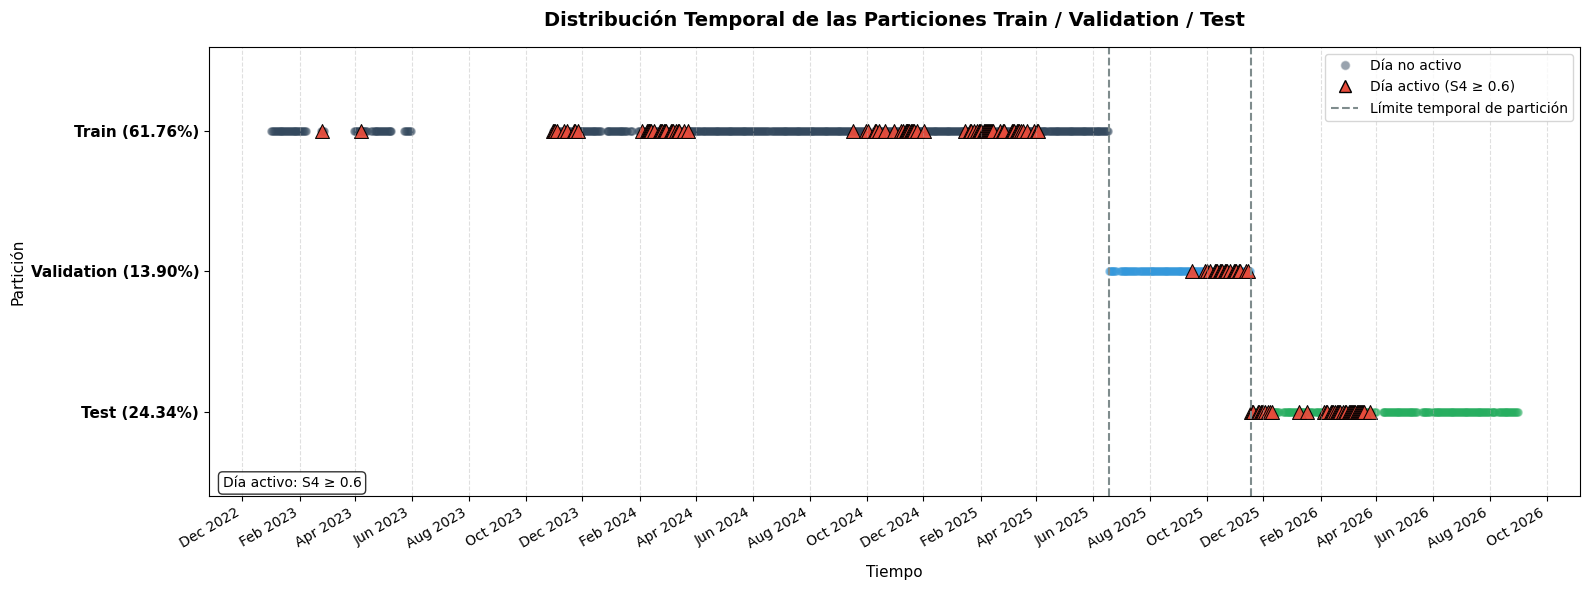

In [53]:
mapa_temporal = visualizar_distribucion_temporal_train_val_test(train_df,val_df,test_df,umbral_s4=S4_EVENT_THRESHOLD)

# **FEATURE ENGINEERING**

In [49]:
# =============================================================================
# 10. FEATURE ENGINEERING TEMPORAL
# =============================================================================

# Definición de Features para el modelo (Orden Importante)
FEATURES_COLS = ["daily_sin","daily_cos","day_of_year_sin","day_of_year_cos","S4"]

def add_temporal_features(df):
    """Agrega periodicidad diaria y anual mediante seno/coseno."""

    out = df.copy()
    idx = pd.DatetimeIndex(out.index)

    minute_of_day = idx.hour * 60 + idx.minute
    daily_period = 24 * 60

    out["daily_sin"] = np.sin(2 * np.pi * minute_of_day / daily_period)
    out["daily_cos"] = np.cos(2 * np.pi * minute_of_day / daily_period)

    # El denominador usa el número de días del año correspondiente.
    day_of_year = idx.dayofyear
    days_in_year = np.where(idx.is_leap_year, 366, 365)

    out["day_of_year_sin"] = np.sin(2 * np.pi * (day_of_year - 1) / days_in_year)
    out["day_of_year_cos"] = np.cos(2 * np.pi * (day_of_year - 1) / days_in_year)

    return out


# Las transformaciones son deterministas respecto al timestamp.
# No aprenden parámetros del futuro y por ello no requieren fit.
train_fe = add_temporal_features(train_df)
val_fe = add_temporal_features(val_df)
test_fe = add_temporal_features(test_df)
#print(train_fe)
missing_features = [c for c in FEATURES_COLS if c not in train_fe.columns]
if missing_features:
    raise ValueError(f"Faltan variables requeridas por FEATURES_COLS: {missing_features}")

print("Features temporales agregadas.")
print(FEATURES_COLS)

Features temporales agregadas.
['daily_sin', 'daily_cos', 'day_of_year_sin', 'day_of_year_cos', 'S4']


In [51]:
train_fe


,S4,daily_sin,daily_cos,day_of_year_sin,day_of_year_cos
Tiempo,,,,,
2023-01-01 00:01:00,0.092,0.004363,0.999990,0.000000,1.000000
2023-01-01 00:02:00,0.092,0.008727,0.999962,0.000000,1.000000
2023-01-01 00:03:00,0.092,0.013090,0.999914,0.000000,1.000000
2023-01-01 00:04:00,0.138,0.017452,0.999848,0.000000,1.000000
2023-01-01 00:05:00,0.093,0.021815,0.999762,0.000000,1.000000
...,...,...,...,...,...
2025-06-17 23:41:00,0.158,-0.082808,0.996566,0.263665,-0.964614
2025-06-17 23:42:00,0.139,-0.078459,0.996917,0.263665,-0.964614
2025-06-17 23:43:00,0.124,-0.074108,0.997250,0.263665,-0.964614


# **ESCALAMIENTO**

In [55]:
# =============================================================================
# 11. ESCALAMIENTO: FIT EXCLUSIVO EN TRAIN
# =============================================================================

import joblib

def create_scaler(scaler_type=SCALER_TYPE):
    if scaler_type.lower() == "minmax":
        return MinMaxScaler(feature_range=(0, 1))
    if scaler_type.lower() == "standard":
        return StandardScaler()
    raise ValueError("SCALER_TYPE debe ser 'minmax' o 'standard'.")


def scale_partitions(train_df, val_df, test_df, features_cols, scaler_type=SCALER_TYPE):
    scaler = create_scaler(scaler_type)

    train_values = train_df[features_cols].astype(float)
    val_values = val_df[features_cols].astype(float)
    test_values = test_df[features_cols].astype(float)

    # CRÍTICO: FIT SOLO EN TRAIN
    scaler.fit(train_values)

    train_scaled = pd.DataFrame(scaler.transform(train_values), index=train_df.index, columns=features_cols)
    val_scaled = pd.DataFrame(scaler.transform(val_values), index=val_df.index, columns=features_cols)
    test_scaled = pd.DataFrame(scaler.transform(test_values), index=test_df.index, columns=features_cols)

    joblib.dump(scaler, "SCALER_S4_CASE0.pkl")

    return train_scaled, val_scaled, test_scaled, scaler


train_scaled, val_scaled, test_scaled, scaler = scale_partitions(train_fe, val_fe, test_fe, FEATURES_COLS)

print("\nScaler:", scaler.__class__.__name__)
print("✓ FIT realizado exclusivamente con TRAIN.")
print("✓ Validation transformado sin FIT.")
print("✓ Test transformado sin FIT.")


Scaler: MinMaxScaler
✓ FIT realizado exclusivamente con TRAIN.
✓ Validation transformado sin FIT.
✓ Test transformado sin FIT.


## **II. ETAPA II**

1. Preparación de datos- Generador de ventanas previo al LSTM
2. Generador de tensores dinamicos para Entrenamiento, Validacion y Testeo.
3. DEfinicion del Modelo y Función de perdida
4. Evaluación, desnormalizar y evaluar
5. Motor del Grid Search Optimizado
6. Ejecución del Pipeline(main)

In [56]:
# =============================================================================
# 12. GENERACIÓN DE VENTANAS TEMPORALES PARA LSTM MULTISTEP
# =============================================================================

def create_lstm_sequences(data_scaled, feature_columns, target_column="S4", lookback=70, horizon=10, sampling_minutes=1, return_metadata=True):
    """
    Genera ventanas temporales para un modelo LSTM multistep.

    X(t) = [t-(lookback-1), ..., t]
    Y(t) = [t+1, ..., t+horizon]

    La función:
    1. Verifica la estructura temporal.
    2. Verifica las variables requeridas.
    3. Detecta gaps.
    4. Evita ventanas que atraviesen gaps.
    5. Devuelve tensores compatibles con Keras.
    6. Opcionalmente devuelve metadatos temporales.

    Debe ejecutarse por separado sobre Train, Validation y Test
    para evitar ventanas que atraviesen los límites entre particiones.
    """

    # =========================================================================
    # 1. VALIDACIONES
    # =========================================================================

    if not isinstance(data_scaled, pd.DataFrame):
        raise TypeError("data_scaled debe ser un pandas.DataFrame.")
    if data_scaled.empty:
        raise ValueError("data_scaled está vacío.")
    if not isinstance(data_scaled.index, pd.DatetimeIndex):
        raise TypeError("El índice de data_scaled debe ser DatetimeIndex.")
    if not data_scaled.index.is_monotonic_increasing:
        raise ValueError("El índice temporal debe estar ordenado cronológicamente.")
    if data_scaled.index.has_duplicates:
        raise ValueError("El índice temporal contiene timestamps duplicados.")
    if target_column not in data_scaled.columns:
        raise ValueError(f"No existe la variable objetivo '{target_column}'.")

    missing_features = [column for column in feature_columns if column not in data_scaled.columns]
    if missing_features:
        raise ValueError(f"Faltan las siguientes variables de entrada: {missing_features}")

    if lookback < 1:
        raise ValueError("lookback debe ser >= 1.")
    if horizon < 1:
        raise ValueError("horizon debe ser >= 1.")
    if sampling_minutes <= 0:
        raise ValueError("sampling_minutes debe ser > 0.")

    # =========================================================================
    # 2. NÚMERO DE OBSERVACIONES
    # =========================================================================

    number_of_rows = len(data_scaled)
    minimum_required_rows = lookback + horizon

    if number_of_rows < minimum_required_rows:
        empty_X = np.empty((0, lookback, len(feature_columns)), dtype=np.float32)
        empty_y = np.empty((0, horizon), dtype=np.float32)

        if return_metadata:
            empty_metadata = pd.DataFrame(columns=["X_start", "X_end", "y_start", "y_end"])
            return empty_X, empty_y, empty_metadata

        return empty_X, empty_y

    # =========================================================================
    # 3. EXTRAER DATOS
    # =========================================================================

    input_values = data_scaled[feature_columns].to_numpy(dtype=np.float32)
    target_values = data_scaled[target_column].to_numpy(dtype=np.float32)
    timestamps = data_scaled.index

    timestamp_ns = timestamps.asi8
    expected_interval_ns = sampling_minutes * 60 * 1_000_000_000

    # =========================================================================
    # 4. DETECTAR GAPS
    # =========================================================================

    timestamp_differences = np.diff(timestamp_ns)
    invalid_intervals = timestamp_differences != expected_interval_ns
    gap_count_prefix = np.concatenate([np.array([0], dtype=np.int64), np.cumsum(invalid_intervals, dtype=np.int64)])

    # =========================================================================
    # 5. CREAR VENTANAS
    # =========================================================================

    X_sequences = []
    y_sequences = []
    metadata = []

    first_forecast_end = lookback - 1
    last_forecast_end = number_of_rows - horizon - 1

    for forecast_end in range(first_forecast_end, last_forecast_end + 1):
        input_start = forecast_end - lookback + 1
        target_end = forecast_end + horizon

        number_of_gaps = gap_count_prefix[target_end] - gap_count_prefix[input_start]

        if number_of_gaps != 0:
            continue

        input_window = input_values[input_start:forecast_end + 1]
        target_window = target_values[forecast_end + 1:target_end + 1]

        X_sequences.append(input_window)
        y_sequences.append(target_window)

        if return_metadata:
            metadata.append({
                "X_start": timestamps[input_start],
                "X_end": timestamps[forecast_end],
                "y_start": timestamps[forecast_end + 1],
                "y_end": timestamps[target_end]
            })

    # =========================================================================
    # 6. CONVERTIR A NUMPY
    # =========================================================================

    if X_sequences:
        X = np.stack(X_sequences).astype(np.float32)
        y = np.stack(y_sequences).astype(np.float32)
    else:
        X = np.empty((0, lookback, len(feature_columns)), dtype=np.float32)
        y = np.empty((0, horizon), dtype=np.float32)

    # =========================================================================
    # 7. METADATOS
    # =========================================================================

    if return_metadata:
        metadata_df = pd.DataFrame(metadata)
        return X, y, metadata_df

    return X, y


# =============================================================================
# 12.1 GENERACIÓN PARA TRAIN / VALIDATION / TEST
# =============================================================================

def generate_lstm_datasets(train_scaled, val_scaled, test_scaled, feature_columns, target_column="S4", lookback=70, horizon=10, sampling_minutes=1):
    """
    Genera las ventanas LSTM de Train, Validation y Test.

    Cada partición se procesa independientemente para evitar
    contaminación temporal entre conjuntos.
    """

    print()
    print("=" * 80)
    print("GENERACIÓN DE VENTANAS LSTM")
    print("=" * 80)
    print(f"LOOKBACK:             {lookback} minutos")
    print(f"HORIZON:              {horizon} minutos")
    print(f"Cadencia esperada:    {sampling_minutes} minuto(s)")
    print(f"Número de features:   {len(feature_columns)}")
    print(f"Variable objetivo:    {target_column}")

    X_train, y_train, meta_train = create_lstm_sequences(train_scaled, feature_columns, target_column, lookback, horizon, sampling_minutes, True)
    X_val, y_val, meta_val = create_lstm_sequences(val_scaled, feature_columns, target_column, lookback, horizon, sampling_minutes, True)
    X_test, y_test, meta_test = create_lstm_sequences(test_scaled, feature_columns, target_column, lookback, horizon, sampling_minutes, True)

    print()
    print("-" * 80)
    print("TRAIN:")
    print(f"   X_train = {X_train.shape}")
    print(f"   y_train = {y_train.shape}")
    print(f"   ventanas = {len(X_train):,}")

    print()
    print("VALIDATION:")
    print(f"   X_val = {X_val.shape}")
    print(f"   y_val = {y_val.shape}")
    print(f"   ventanas = {len(X_val):,}")

    print()
    print("TEST:")
    print(f"   X_test = {X_test.shape}")
    print(f"   y_test = {y_test.shape}")
    print(f"   ventanas = {len(X_test):,}")

    print("-" * 80)

    return X_train, y_train, meta_train, X_val, y_val, meta_val, X_test, y_test, meta_test


# =============================================================================
# 12.2 EJECUCIÓN
# =============================================================================

X_train, y_train, meta_train, X_val, y_val, meta_val, X_test, y_test, meta_test = generate_lstm_datasets(
    train_scaled=train_scaled,
    val_scaled=val_scaled,
    test_scaled=test_scaled,
    feature_columns=FEATURES_COLS,
    target_column=TARGET_COL,
    lookback=LOOKBACK,
    horizon=HORIZON,
    sampling_minutes=SAMPLING_MINUTES,
)


GENERACIÓN DE VENTANAS LSTM
LOOKBACK:             70 minutos
HORIZON:              10 minutos
Cadencia esperada:    1 minuto(s)
Número de features:   5
Variable objetivo:    S4

--------------------------------------------------------------------------------
TRAIN:
   X_train = (850568, 70, 5)
   y_train = (850568, 10)
   ventanas = 850,568

VALIDATION:
   X_val = (189050, 70, 5)
   y_val = (189050, 10)
   ventanas = 189,050

TEST:
   X_test = (331697, 70, 5)
   y_test = (331697, 10)
   ventanas = 331,697
--------------------------------------------------------------------------------


# **VALIDACION DE VENTANAS**

In [57]:
# =============================================================================
# 13. VALIDACIÓN DE VENTANAS
# =============================================================================

def validate_sequences(X, y, meta, lookback, horizon, name):
    if X.ndim != 3:
        raise AssertionError(f"{name}: X debe ser 3D.")
    if y.ndim != 2:
        raise AssertionError(f"{name}: y debe ser 2D.")

    if X.shape[0] != y.shape[0] or X.shape[0] != len(meta):
        raise AssertionError(f"{name}: número de muestras inconsistente.")

    if X.shape[1] != lookback:
        raise AssertionError(f"{name}: lookback incorrecto.")

    if y.shape[1] != horizon:
        raise AssertionError(f"{name}: horizon incorrecto.")

    if len(meta):
        if not (meta["X_end"] < meta["y_start"]).all():
            raise AssertionError(
                f"{name}: existe solapamiento entre X y Y."
            )

    print(
        f"✓ {name}: {X.shape[0]:,} ventanas válidas | "
        f"X={X.shape} | y={y.shape}"
    )


validate_sequences(X_train, y_train, meta_train, LOOKBACK, HORIZON, "TRAIN")
validate_sequences(X_val, y_val, meta_val, LOOKBACK, HORIZON, "VALIDATION")
validate_sequences(X_test, y_test, meta_test, LOOKBACK, HORIZON, "TEST")


def validate_no_cross_partition_windows(meta_train, meta_val, meta_test):
    """Verifica que las ventanas no atraviesen los límites."""

    if len(meta_train) and len(meta_val):
        if meta_train["y_end"].max() >= meta_val["X_start"].min():
            raise AssertionError("Posible solapamiento temporal Train/Validation.")

    if len(meta_val) and len(meta_test):
        if meta_val["y_end"].max() >= meta_test["X_start"].min():
            raise AssertionError("Posible solapamiento temporal Validation/Test.")

    print("✓ No existen ventanas cruzando límites de partición.")


validate_no_cross_partition_windows( meta_train, meta_val, meta_test)

✓ TRAIN: 850,568 ventanas válidas | X=(850568, 70, 5) | y=(850568, 10)
✓ VALIDATION: 189,050 ventanas válidas | X=(189050, 70, 5) | y=(189050, 10)
✓ TEST: 331,697 ventanas válidas | X=(331697, 70, 5) | y=(331697, 10)
✓ No existen ventanas cruzando límites de partición.
